<a href="https://colab.research.google.com/github/marianarada/ciencia-datos-clase/blob/main/Proyecto_clustering_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

#**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

#*Proyecto I*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Proyecto Final – Clustering de clientes**

## **Tema del proyecto**
**Modelo de Segmentación de Clientes basado en Ingeniería de Características y Aprendizaje No Supervisado**

**Dataset:**

E-Commerce Customer Behavior and Sales (2020-2026)

## **Integrantes**
- Ceneida Aliceth  Durango Sánchez
- Mariana Rada Espitia
- Juan Esteban Amariles Atehortua
- Cristhian Alexander Bejarano Murillo



## **Docente**
**Nicolas Gomez Giraldo**

## **Fecha**
**15/05/2026**

## **CONTEXTO DEL CONJUNTO DE DATOS:**
#
**Origen y procedencia de los datos**

El dataset utilizado para realizar este proyecto corresponde al **E-Commerce Customer Behavior and Sales (2020-2026)**, disponible en la plataforma **Kaggle**. Este conjunto de datos simula un entorno transaccional y de clasificacón demográfica de un comercio electronico durante un periodo de seis años, integrando toda la informacion a nivel cliente (`customers`) y el detalle de todas las transacciones individuales por cliente (`ordes`).
En vista de que los datos representan un entorno comercial genérico, se tomo la desición de emprender una prespectiva de aprendizaje no supervisado (Clustering) y análisis exploratorio, para con sigo encontrar patrones de compra, nivel de lealtad (RFM) y comportamientos que permitan segmentar los clientes que tengan características homogéneas.
#
** Situación u problema**

En el sector del comercio electrónico, donde se encuentra competencia cada vez más fuerte y los datos crecen constantemente, en estos tiempos ya no es acertivo tratar a todos los clientes de la misma manera. Ahora, las compañias requieres entender realmente que tipo de clientes están detras de cada compra: qué les gusta comprar, que tipo de producto, con que frecuencia y como interactúan con la plataforma o pagina web.

Para lograr este objetivo, se analizan aspectos como, cuanto dinero gastan, con que frecuencia lo hacen, el tiempo transcurrido desde la última compra esto se conoce como **(RFM)**, así tambien el comportamiento de interaccion en la plataforma, cuánto tiempo navegan, qué páginas visitan o cuál es su método de pago de predilección.
#
** Informacion general que contiene el conjunto de datos**

Tras integrar y consolidar toda la informacion, se obtuvo un dataset de 8.000 clientes únicos a partir de 25.000 órdenes de compra. El conjunto final incluye 40 variables, construidas mediante ingeniería de características y codificación, que abarcan aspectos demográficos, de comportamiento, interacción y preferencias.

Antes del modelamiento, se realizó u
na adecuada limpieza y preparación de los datos, tratando valores atípicos y evaluando la correlación y varianza. Esto permite aplicar modelos de clustering como K-Means de forma más confiable, logrando segmentaciones más estables y representativas.
#
** Objetivo del análisis**

El objetico de este proyecto es crear agrupaciones de los clientes según su comportamiento, utilizando técnicas de aprendizaje no supervisado. La idea es segmentar a los 8.000 clientes en distintos grupos los cuales asignaremos a medida de que realicemos EDA, Feature Engineering y respectrivo modelado.
#
** Variables Observadas y direcctorio del Dataset**

Para construir el dataset que se utilizara en el modelo de segmentacion (Clustering), se consolido toda la informacion demográfica de los clientes relacionando el comportamiento histoórico de sus compras. A continuacion se detallara cada uno de los Dataset utilizados en el proyecto, con el fin de darle a los lectores una claridad mas organizada de cada una de las variables analizadas en cada Datasrt.
#
** Variables del Dataset (`customers`)**
#
| Nombre de la variable | Descripción | Tipo de Variable | Unidades | Rango observado / Valores | Rol en el análisis |
|---|---|---|---|---|---|
| `customer_id` | Código único de identificación del cliente. | Identificador (cualitativa nominal) | — | C00001 a C08000 | Identificador (excluido del modelo) |
| `country` | País de residencia del comprador. | Categórica nominal | — | 20 países distintos | Perfil demográfico (excluido del modelo) |
| `age` | Edad del cliente en años. | Cuantitativa continua | Años | 18 a 75 | Variable demográfica activa |
| `gender` | Género con el que se identifica el usuario. | Categórica nominal | — | Female, Male, Other | One-Hot Encoding |
| `membership_tier` | Nivel del programa de fidelización. | Categórica ordinal | — | Free, Silver, Gold, Platinum | Label Encoding (0 a 3) |
| `preferred_category` | Categoría donde el cliente compra con mayor frecuencia. | Categórica nominal | — | 14 categorías comerciales | One-Hot Encoding |
| `preferred_device` | Dispositivo más utilizado por el usuario. | Categórica nominal | — | Mobile, Desktop, Tablet | One-Hot Encoding |
| `preferred_payment_method` | Medio de pago más frecuente. | Categórica nominal | — | 7 métodos de pago | One-Hot Encoding |
| `acquisition_channel` | Canal de marketing por el cual llegó el cliente. | Categórica nominal | — | 6 canales digitales | One-Hot Encoding |
| `churned` | Indica si el cliente ha abandonado la marca. | Binaria (0/1) | — | 0 (No), 1 (Sí) | Validación externa (excluido del modelo) |
#
**Nota:**

- En este archivo, `churne` toma valores 0/1, por lo que se interpreta como indicador binario de abandona/no abandona la marca o tienda eléctronica.
#
** Variables del Dataset (`orders`)**
#
| Nombre de la variable | Descripción | Tipo | Unidades | Rango observado / Valores | Rol en el análisis |
|---|---|---|---|---|---|
| `order_id` | Código único de la orden de compra. | Identificador (alfanumérico) | — | — | Llave primaria transaccional |
| `product_name` | Nombre específico del artículo vendido. | Categórica nominal | — | — | Detalle operativo |
| `category` | Clasificación comercial del producto. | Categórica nominal | — | — | Agrupador operativo |
| `unit_price_usd` | Precio unitario del artículo. | Cuantitativa continua | USD | — | Control de precios |
| `quantity` | Unidades compradas en la transacción. | Cuantitativa discreta | Unidades | — | Volumen de la orden |
| `subtotal_usd` | Costo bruto de los artículos. | Cuantitativa continua | USD | — | Base de cálculo |
| `discount_pct` | Porcentaje de descuento aplicado. | Cuantitativa continua | % | — | Control promocional |
| `discount_amount_usd` | Monto descontado en la transacción. | Cuantitativa continua | USD | — | Control promocional |
| `total_amount_usd` | Monto final pagado por la orden. | Cuantitativa continua | USD | — | Base para valor monetario |
| `payment_method` | Medio de pago usado en la transacción. | Categórica nominal | — | — | Registro transaccional |
| `device_used` | Dispositivo usado en la compra. | Categórica nominal | — | — | Registro transaccional |
| `delivery_days` | Días transcurridos para la entrega. | Cuantitativa discreta | Días | — | Eficiencia logística |
| `returned` | Estado de devolución de la orden. | Binaria (0/1) | — | 0 = No, 1 = Sí | Control de calidad |
| `session_duration_minutes` | Tiempo de navegación previo a la compra. | Cuantitativa continua | Minutos | — | Métrica de navegación |
| `pages_viewed_before_purchase` | Páginas visitadas antes del pago. | Cuantitativa discreta | Páginas | — | Métrica de navegación |
#
**Nota:**

- En este archivo, `returned` toma valores 0/1, por lo que se interpreta como indicador binario de se quedo con el producto/solicito devolución del producto.
#
** Variables contruidas y procesadas**
#
| Nombre de la variable | Descripción | Tipo | Unidades | Rango observado / Valores | Rol en el análisis |
|---|---|---|---|---|---|
| `days_since_last_purchase` | Días desde la última compra del cliente. | Cuantitativa continua | Días | 0 a 186 (Winsorizado) | Métrica clave: Recencia (R) |
| `total_ordenes_or` | Frecuencia total de compras del usuario. | Cuantitativa discreta | — | 1.10 a 2.38 (escala log) | Métrica clave: Frecuencia (F) |
| `total_comprado_usd_or` | Dinero total gastado por el cliente. | Cuantitativa continua | USD | 3.13 a 8.18 (escala log) | Métrica clave: Valor Monetario (M) |
| `total_descuento_usd_or` | Total de descuentos aprovechados. | Cuantitativa continua | USD | -4.92 a 8.21 (escala log) | Sensibilidad a promociones |
| `cantidad_devoluciones_or` | Total de órdenes devueltas. | Cuantitativa discreta | — | 0.00 a 0.00 (mayoría en 0) | Indicador de fricción |
| `cantidad_metodos_pago_or` | Número de métodos de pago utilizados. | Cuantitativa discreta | Métodos | 1 a 6 | Versatilidad transaccional |
| `registration_date_antiguedad_dias` | Días desde el registro del cliente. | Cuantitativa discreta | Días | 43 a 5,398 | Antigüedad / lealtad |
| `avg_session_min` | Tiempo promedio de navegación por sesión. | Cuantitativa continua | Minutos | 3.70 (valor escalado) | Engagement digital |
| `avg_paginas_vistas` | Páginas promedio vistas antes de comprar. | Cuantitativa continua | Páginas | 1.00 (valor escalado) | Intensidad de búsqueda |
#
La comprensión de cada variabler y para qué sirve es fundamental para que el modelo tenga sentido en el proyecto, no solo en lo técnico. Con vas variables ya organizadas, se procede a la carga de Dataset, EDA y Feature Engeneering.


## **2. CARGA DE DATOS Y PREPARACIÓN**

**2.1. Importación de librerias y configuración del entorno**

Se configura el entorno de trabajo con el fin de poder realizar una manipulación matricial, en el area estadistica y futuro aprendizaje del modelo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats.mstats import winsorize
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Librerias cargadas correctamente')
print("-------------------------------")
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

Librerias cargadas correctamente
-------------------------------
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


**2.2. Carga de Dataset**

Se establece la linea base del proyecto, confirmando el volumen inicial para cada Dataset 8.000 registros para el de `customers` con 20 variables y 25.000 registros para el de `orders` con 28 variables.

In [ ]:
print('Cargar datasets')
RUTA_CUSTOMERS = '/content/drive/MyDrive/Proyecto1/customers.csv'
RUTA_ORDERS    = '/content/drive/MyDrive/Proyecto1/orders.csv'

df_cust = pd.read_csv(RUTA_CUSTOMERS)
df_ord  = pd.read_csv(RUTA_ORDERS)

print("-----------------------------------------")
print(f'customers  -> {df_cust.shape[0]:,} filas x {df_cust.shape[1]} columnas')
print(f'orders     -> {df_ord.shape[0]:,} filas x {df_ord.shape[1]} columnas')



Cargar datasets
-----------------------------------------
customers  -> 8,000 filas x 20 columnas
orders     -> 25,000 filas x 28 columnas


In [ ]:
df_cust.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.50,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.60,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.80,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.20,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.00,4,5,1,0


In [ ]:
df_ord.head()

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_pct,tax_amount_usd,total_amount_usd,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,1,62.91,0,0.00,0.00,18,11.32,74.23,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.40,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,1,18.44,0,0.00,3.99,10,1.84,24.27,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.00,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,1,109.79,20,21.96,0.00,8,7.03,94.86,PayPal,Desktop,3,2023-06-28,Delivered,0,4.00,3.20,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,1,87.21,50,43.60,0.00,8,3.49,47.10,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.20,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,2,188.60,0,0.00,9.99,5,9.43,208.02,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.80,54.70,2,1


 **2.3. Ingenieria de características transaccionales (agrupación)**

Para que el algoritmo trabaje de manera óptima requiere que se realice una segmenteción unica por cada fila de cliente, como el Dataset de `orders` tiene múltiples filas por pesona, es de suma importancia agrupar y extraer métricas, con esta técnica se permite construir la base del modelo **RFM** y el nivel de **engagemment** (tiempo en linea o paginas vistas) de cada cliente o usuario.

In [ ]:
print('Se agrupa el Dataset de órdenes por cliente para obtener variables de comportamiento a nivel cliente, necesarias para el clustering\n')
df_ordenes = df_ord.copy()

df_resumen_ordenes = df_ordenes.groupby('customer_id').agg(
    num_categorias_compradas_or   = ('category',                    'nunique'),
    total_ordenes_or    = ('order_id',                   'nunique'),
    total_descuento_usd_or = ('discount_amount_usd',                'sum'),
    total_comprado_usd_or   = ('total_amount_usd',                'sum'),
    cantidad_devoluciones_or = ('returned',                lambda x: (x == 1).sum()),
    cantidad_metodos_pago_or = ('payment_method',                'nunique'),
    avg_delivery_days = ('delivery_days',                'mean'),
    avg_session_min   = ('session_duration_minutes',     'mean'),
    avg_paginas_vistas  = ('pages_viewed_before_purchase', 'mean'),
    device_mas_usado  = ('device_used',  lambda x: x.value_counts().index[0]),
    metodo_pago_pref  = ('payment_method', lambda x: x.value_counts().index[0]),
).reset_index()

display(df_resumen_ordenes.head(3))

Se agrupa el Dataset de órdenes por cliente para obtener variables de comportamiento a nivel cliente, necesarias para el clustering



,customer_id,num_categorias_compradas_or,total_ordenes_or,total_descuento_usd_or,total_comprado_usd_or,cantidad_devoluciones_or,cantidad_metodos_pago_or,avg_delivery_days,avg_session_min,avg_paginas_vistas,device_mas_usado,metodo_pago_pref
0,C00001,2,2,0.00,511.55,0,2,2.00,8.95,8.50,Mobile,PayPal
1,C00002,3,4,3.91,863.67,1,3,3.25,16.65,8.25,Mobile,PayPal
2,C00003,3,3,12.89,251.44,0,2,5.67,6.53,8.67,Mobile,PayPal



Al agrupar el historial de órdenes por cliente, se calcularon las siguientes métricas clave para el modelo de Clustering:

| Variable | ¿Qué cálculo hace? | Justificación Analítica |
| :--- | :--- | :--- |
| **`num_categorias_compradas_or`** | Cuenta categorías únicas compradas (`nunique`). | Mide la diversidad de intereses y la penetración del cliente en el catálogo. |
| **`total_ordenes_or`** | Cuenta IDs de orden únicos (`nunique`). | **Frecuencia (F)** del modelo RFM. Mide el número real de "carritos de compra" pagados. |
| **`total_descuento_usd_or`** | Suma el dinero ahorrado en descuentos (`sum`). | Identifica clientes altamente sensibles al precio ("cazadores de ofertas"). |
| **`total_comprado_usd_or`** | Suma el monto final pagado (`sum`). | **Valor Monetario (M)** del RFM. Define el valor que el cliente aporta al negocio (CLV). |
| **`cantidad_devoluciones_or`** | Suma las órdenes devueltas (`sum` de 1s). | Indicador de insatisfacción o fricción. Ayuda a detectar clientes operativamente costosos. |
| **`cantidad_metodos_pago_or`** | Cuenta métodos de pago distintos (`nunique`). | Mide la versatilidad financiera y el nivel de confianza en la plataforma. |
| **`avg_delivery_days`** | Promedia los días de entrega (`mean`). | Evalúa si demoras logísticas pueden ser causa de abandono (*churn*). |
| **`avg_session_min`** | Promedia los minutos por sesión (`mean`). | Métrica de *Engagement*. Diferencia a compradores impulsivos de los analíticos. |
| **`avg_paginas_vistas`** | Promedia las páginas visitadas (`mean`). | Complementa el *Engagement* midiendo la profundidad de navegación. |
| **`device_mas_usado`*** | Calcula el dispositivo más frecuente (Moda). | Segmenta preferencias tecnológicas para optimizar campañas de marketing. |
| **`metodo_pago_pref`*** | Calcula el medio de pago favorito (Moda). | Útil para diseñar estrategias de fidelización (ej. alianzas con tarjetas). |



**2.4. Limpieza inicial del inicial del perfil customers**

Se eliminaran variables agregas las cuales venian contaminando el Dataset `customers` para evitar datos redundantes y **(Data leakage)**, esto se realiza con el fin de asegurar la precisión de la metrica.

In [ ]:
print('ESTADO INICIAL DEL DATASET')
print("-----------------------------------------")
resumen = pd.DataFrame({
    'Tipo'       : df_cust.dtypes,
    'Nulos'      : df_cust.isnull().sum(),
    'Nulos %'    : (df_cust.isnull().sum() / len(df_cust) * 100).round(1),
    'Unicos'     : df_cust.nunique(),
    'Muestra'    : [str(df_cust[c].dropna().iloc[0]) if len(df_cust[c].dropna()) > 0 else '' for c in df_cust.columns]
})

print(f'Filas      : {df_cust.shape[0]:,}')
print(f'Columnas   : {df_cust.shape[1]}')
print(f'Con nulos  : {(resumen["Nulos"] > 0).sum()}')
print(f'Duplicados : {df_cust.duplicated().sum()}')
print()
display(resumen)

ESTADO INICIAL DEL DATASET
-----------------------------------------
Filas      : 8,000
Columnas   : 20
Con nulos  : 0
Duplicados : 0



,Tipo,Nulos,Nulos %,Unicos,Muestra
customer_id,object,0,0.00,8000,C00001
country,object,0,0.00,20,United States
age,int64,0,0.00,57,40
gender,object,0,0.00,3,Male
membership_tier,object,0,0.00,4,Free
registration_date,object,0,0.00,1862,2019-01-17
total_orders,int64,0,0.00,79,4
total_spend_usd,float64,0,0.00,7864,286.63
avg_order_value_usd,float64,0,0.00,6365,63.78
days_since_last_purchase,int64,0,0.00,336,49


In [ ]:
columnas_a_eliminar = ['total_orders', 'total_spend_usd', 'returns_made', 'newsletter_subscribed']
df_cust.drop(columns=columnas_a_eliminar, inplace=True)

print(f'se han eliminado las siguientes columnas cuya información la vamos a tomar del DF de orders: {columnas_a_eliminar}\n')


se han eliminado las siguientes columnas cuya información la vamos a tomar del DF de orders: ['total_orders', 'total_spend_usd', 'returns_made', 'newsletter_subscribed']




**2.5. Consolidación de la matriz de Datos (Merge)**

Se unifica `orders` con `customers` por `customer_id` **(left join desde orders)**.
El resultado tiene **una fila por transaccion** enriquecida con el perfil del cliente, se realizara una imputacion de nulos con ceros para reflejar la inactividad de los usuarios.

In [ ]:
print('Se cruzarán los datasets Customer y Orders para obtener un dataset con toda la información de comportamiento de los clientes a partir de sus compras\n')
df = df_cust.merge(df_resumen_ordenes, on='customer_id', how='left', suffixes=('_ord', '_cust')).fillna({
    'num_categorias_compradas_or': 0,
    'total_ordenes_or': 0,
    'total_descuento_usd_or': 0,
    'total_comprado_usd_or': 0,
    'cantidad_devoluciones_or': 0,
    'cantidad_metodos_pago_or': 0,
    'avg_delivery_days': df_resumen_ordenes['avg_delivery_days'].mean(),
    'avg_session_min': df_resumen_ordenes['avg_session_min'].mean(),
    'avg_paginas_vistas': df_resumen_ordenes['avg_paginas_vistas'].mean(),
    'device_mas_usado': 'Unknown',
    'metodo_pago_pref': 'Unknown'
})

print(f'Dataset cruzado -> {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Clientes unicos  : {df["customer_id"].nunique():,}  (de {df_cust.shape[0]:,} en customers)')


Se cruzarán los datasets Customer y Orders para obtener un dataset con toda la información de comportamiento de los clientes a partir de sus compras

Dataset cruzado -> 8,000 filas x 27 columnas
Clientes unicos  : 8,000  (de 8,000 en customers)


## **3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

**3.1. Formateo y clasificación de variables**

En esta estapa del proyecto se realizara una auditoria tecnica, con el fin de consolidar un Dataset limpio, el cual nos permitira separar logicamente las variables aplicando tratamientos de forma automatizada, tambien se tomara la decision de aislar la variable `customer_id`la cual no aporta un valor matematico, si no identificacion alfanumerica de cada cliente, tambien el `churned`que se utilizara de apoyo para perfilar a los clientes al final, más no para crearlos.

In [ ]:
print('Identificar columnas de fecha en formato string')
print("-------------------------------------------------")

date_cols = [df.columns[df.columns.str.lower().str.contains('date|fecha', case=False, regex=True)].tolist()]
date_cols = [col for sublist in date_cols for col in sublist]  # aplanar la lista de listas

print('Columnas de fecha detectadas:', date_cols)

Identificar columnas de fecha en formato string
-------------------------------------------------
Columnas de fecha detectadas: ['registration_date']


In [ ]:
print('Convertir columnas de fecha a formato datetime')
print("-------------------------------------------------")

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'columna de fecha convertida a datetime: {col}')


Convertir columnas de fecha a formato datetime
-------------------------------------------------
columna de fecha convertida a datetime: registration_date


- Se identifica la variable `registration_date_antiguedad_dias` en formato string, lo cual impide realizar un análisis temporal adecuado. Por esta razón, se procede a convertirla a formato tipo fecha, permitiendo así un análisis correcto de la antigüedad de cada cliente.

In [ ]:
print('ENCABEZADO INICIAL DEL DATASET')
print("-------------------------------------------------")

display(df.head(3))

ENCABEZADO INICIAL DEL DATASET
-------------------------------------------------


,customer_id,country,age,gender,membership_tier,registration_date,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,wishlist_items,churned,num_categorias_compradas_or,total_ordenes_or,total_descuento_usd_or,total_comprado_usd_or,cantidad_devoluciones_or,cantidad_metodos_pago_or,avg_delivery_days,avg_session_min,avg_paginas_vistas,device_mas_usado,metodo_pago_pref
0,C00001,United States,40,Male,Free,2019-01-17,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.50,12,0,2.00,2.00,0.00,511.55,0.00,2.00,2.00,8.95,8.50,Mobile,PayPal
1,C00002,United States,20,Female,Free,2026-03-04,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.60,1,0,3.00,4.00,3.91,863.67,1.00,3.00,3.25,16.65,8.25,Mobile,PayPal
2,C00003,United States,43,Female,Gold,2026-02-08,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.80,0,0,3.00,3.00,12.89,251.44,0.00,2.00,5.67,6.53,8.67,Mobile,PayPal


In [ ]:
print('ESTADO INICIAL DEL DATASET \n')
resumen = pd.DataFrame({
    'Tipo'       : df.dtypes,
    'Nulos'      : df.isnull().sum(),
    'Nulos %'    : (df.isnull().sum() / len(df) * 100).round(1),
    'Unicos'     : df.nunique(),
    'Muestra'    : [str(df[c].dropna().iloc[0]) if len(df[c].dropna()) > 0 else '' for c in df.columns]
})

print(f'Filas      : {df.shape[0]:,}')
print(f'Columnas   : {df.shape[1]}')
print(f'Con nulos  : {(resumen["Nulos"] > 0).sum()}')
print(f'Duplicados : {df.duplicated().sum()}')
print()
display(resumen)

ESTADO INICIAL DEL DATASET 

Filas      : 8,000
Columnas   : 27
Con nulos  : 0
Duplicados : 0



,Tipo,Nulos,Nulos %,Unicos,Muestra
customer_id,object,0,0.00,8000,C00001
country,object,0,0.00,20,United States
age,int64,0,0.00,57,40
gender,object,0,0.00,3,Male
membership_tier,object,0,0.00,4,Free
registration_date,datetime64[ns],0,0.00,1862,2019-01-17 00:00:00
avg_order_value_usd,float64,0,0.00,6365,63.78
days_since_last_purchase,int64,0,0.00,336,49
preferred_category,object,0,0.00,14,Food & Grocery
preferred_device,object,0,0.00,3,Mobile


- Tras asegurar que todas las variables no presentan datos nulos y cuentan con el tipo de formato adecuado para su análisis, se procede con el procesamiento de las variables descritas en el punto 3.1.

In [ ]:
print('Separar columnas por tipo')
print("-------------------------------------------------")

# customer_id y churned se tratan por separado
ID_COL      = 'customer_id'      # NO se usa para clustering, solo para identificar clientes
TARGET_COL  = 'churned'          # NO se usa para clustering, solo para validar

bin_cols = [col for col in df.columns
            if df[col].nunique() == 2
            and df[col].dtype in ['int64', 'float64', 'uint8']
            and col not in [ID_COL, TARGET_COL]] # binarias (0/1)

num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in [ID_COL, TARGET_COL, *bin_cols]]

cat_cols  = [col for col in df.columns if df[col].dtype in ['object', 'category', 'string'] and col not in [ID_COL, TARGET_COL]]

date_cols = [col for col in df.columns if df[col].dtype in ['datetime64[ns]', 'datetime64[us]']]


# # Columnas RFM — las mas importantes para segmentacion de clientes
rfm_cols = {
    'Recency'   : 'days_since_last_purchase',  # cuanto tiempo sin comprar
    'Frequency' : 'total_ordenes_or',              # cuantas veces compro
    'Monetary'  : 'total_comprado_usd_or'            # cuanto gasto en total
}

print(f'Columnas numericas  ({len(num_cols)}): {num_cols}')
print(f'Columnas categoricas ({len(cat_cols)}): {cat_cols}')
print(f'Columnas binarias   ({len(bin_cols)}): {bin_cols}')
print(f'Columnas de fecha   ({len(date_cols)}): {date_cols}')
print(f'Columnas RFM        : {list(rfm_cols.values())}')

Separar columnas por tipo
-------------------------------------------------
Columnas numericas  (15): ['age', 'avg_order_value_usd', 'days_since_last_purchase', 'reviews_given', 'avg_review_score', 'wishlist_items', 'num_categorias_compradas_or', 'total_ordenes_or', 'total_descuento_usd_or', 'total_comprado_usd_or', 'cantidad_devoluciones_or', 'cantidad_metodos_pago_or', 'avg_delivery_days', 'avg_session_min', 'avg_paginas_vistas']
Columnas categoricas (9): ['country', 'gender', 'membership_tier', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'device_mas_usado', 'metodo_pago_pref']
Columnas binarias   (0): []
Columnas de fecha   (1): ['registration_date']
Columnas RFM        : ['days_since_last_purchase', 'total_ordenes_or', 'total_comprado_usd_or']


- La separacion de todas las variables por tipo de dato permite aplicar transformaciones adecuadas y específicas para cada proceso, optimizando el análisis y modelado. Al igual, que se excluyan variables no relevantes para el `clustering` destacando las variables **(RFM)** por la importancia en la segmentación de clientes.

In [ ]:
print('Resumen de columnas')
print("-------------------------------------------------")

def clasificar_columna(col, df):
    if ID_COL  and col == ID_COL:
        return 'Excluir — identificador'
    if TARGET_COL and col == TARGET_COL:
        return 'Excluir — validación externa'
    if col in date_cols:
        return 'Transformar — extraer componentes'
    if col in cat_cols:
        return f'Categoricas ({df[col].nunique()} valores)'
    if col in bin_cols:
        return 'Binaria (0/1)'
    return 'Numerica — escalar'

estado_inicial = pd.DataFrame({
    'tipo'      : df.dtypes,
    'nulos'     : df.isnull().sum(),
    'pct_nulos' : (df.isnull().sum() / len(df) * 100).round(1),
    'unicos'    : df.nunique(),
    'rol'       : [clasificar_columna(c, df) for c in df.columns]
})

display(
    estado_inicial
    .style
    .map(
        lambda v: 'background-color: #e60000; color: white; font-weight: bold' if 'Excluir' in str(v) \
            else 'background-color: #ffcc00; color: black; font-weight: bold' if 'Transformar' in str(v) \
            else 'background-color: #00cc00; color: black; font-weight: bold' if 'Numerica' in str(v) \
            else 'background-color: #0073e6; color: white; font-weight: bold' if 'Categoricas' in str(v) \
            else '',
        subset=['rol']
            )
)

print(f'\nColumnas totales           : {df.shape[1]}')
print(f'Columnas a excluir         : {estado_inicial["rol"].str.contains("Excluir").sum()}')
print(f'Columnas numéricas         : {estado_inicial["rol"].str.contains("Numerica").sum()}')
print(f'Columnas categóricas       : {estado_inicial["rol"].str.contains("Categoricas").sum()}')
print(f'Columnas a transformar     : {estado_inicial["rol"].str.contains("Transformar").sum()}')
print(f'Total nulos en el dataset  : {df.isnull().sum().sum()}')

Resumen de columnas
-------------------------------------------------


,tipo,nulos,pct_nulos,unicos,rol
customer_id,object,0,0.000000,8000,Excluir — identificador
country,object,0,0.000000,20,Categoricas (20 valores)
age,int64,0,0.000000,57,Numerica — escalar
gender,object,0,0.000000,3,Categoricas (3 valores)
membership_tier,object,0,0.000000,4,Categoricas (4 valores)
registration_date,datetime64[ns],0,0.000000,1862,Transformar — extraer componentes
avg_order_value_usd,float64,0,0.000000,6365,Numerica — escalar
days_since_last_purchase,int64,0,0.000000,336,Numerica — escalar
preferred_category,object,0,0.000000,14,Categoricas (14 valores)
preferred_device,object,0,0.000000,3,Categoricas (3 valores)



Columnas totales           : 27
Columnas a excluir         : 2
Columnas numéricas         : 15
Columnas categóricas       : 9
Columnas a transformar     : 1
Total nulos en el dataset  : 0


- Se construye una tabla resumen con el fin de una facil identificacion, cantidad de valores nulos y rol dentro del análisis. Esto nos permitira validar y corroborar que variables se deben excluir, transformarse o escalarse, facilitando la preparación de datos para el modelado.

**3.2. Evaluacion de asimetría (Skewnees) y multimodalidad**

El algoritmo es muy sencible a distribuciones asimétricas porque se basa en la creación de sus grupos en la media (centroides). Identificar asimetrías fuertes (Skewnees>1) nos da la justicicaión para aplicas transformacion, garantizando grupos más estables y lógicos.

In [ ]:
desc = df[[col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in [ID_COL, TARGET_COL, *bin_cols]]].describe().T
desc['skewness'] = df[num_cols].skew().round(2)
desc['kurtosis'] = df[num_cols].kurtosis().round(2)

display(
    desc.style
    .background_gradient(subset=['skewness'], cmap='RdYlGn_r')
    .format(precision=2)
)

print('INTERPRETACION DEL SKEWNESS:')
print("------------------------------------------------------------------------------------------------------------------------")
print(f'  |skewness| < 0.5  -> distribucion simetrica     -> OK para clustering directo:  {", ".join([c for c in num_cols if abs(df[c].skew()) < 0.5])}')
print(f'  |skewness| 0.5-1  -> sesgo leve                 -> considerar transformacion: {", ".join([c for c in num_cols if 0.5 <= abs(df[c].skew()) <= 1])}')
print(f'  |skewness| > 1    -> sesgo fuerte               -> TRANSFORMAR con log antes del clustering: {", ".join([c for c in num_cols if abs(df[c].skew()) > 1])}')
print()
sesgadas = [c for c in num_cols if abs(df[c].skew()) > 1]

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,8000.00,35.62,11.17,18.00,27.00,35.00,43.00,75.00,0.32,-0.40
avg_order_value_usd,8000.00,94.85,78.99,5.00,44.69,72.27,118.56,1051.73,2.85,14.58
days_since_last_purchase,8000.00,59.58,60.61,0.00,16.00,41.00,84.00,582.00,2.05,6.40
reviews_given,8000.00,3.23,3.94,0.00,0.00,2.00,5.00,28.00,2.05,5.30
avg_review_score,8000.00,4.11,0.52,1.80,3.80,4.20,4.50,5.00,-0.76,0.37
wishlist_items,8000.00,4.46,4.85,0.00,1.00,3.00,6.00,41.00,1.89,4.89
num_categorias_compradas_or,8000.00,2.69,1.41,0.00,2.00,3.00,4.00,8.00,0.38,-0.04
total_ordenes_or,8000.00,3.12,1.76,0.00,2.00,3.00,4.00,12.00,0.58,0.35
total_descuento_usd_or,8000.00,19.83,32.81,0.00,0.00,7.53,25.64,432.17,3.67,21.61
total_comprado_usd_or,8000.00,392.05,338.51,0.00,151.21,308.73,537.22,3602.81,1.80,5.54


INTERPRETACION DEL SKEWNESS:
------------------------------------------------------------------------------------------------------------------------
  |skewness| < 0.5  -> distribucion simetrica     -> OK para clustering directo:  age, num_categorias_compradas_or, cantidad_metodos_pago_or
  |skewness| 0.5-1  -> sesgo leve                 -> considerar transformacion: avg_review_score, total_ordenes_or
  |skewness| > 1    -> sesgo fuerte               -> TRANSFORMAR con log antes del clustering: avg_order_value_usd, days_since_last_purchase, reviews_given, wishlist_items, total_descuento_usd_or, total_comprado_usd_or, cantidad_devoluciones_or, avg_delivery_days, avg_session_min, avg_paginas_vistas



Distribuciones con deteccion de multimodalidad 
---------------------------------------------------


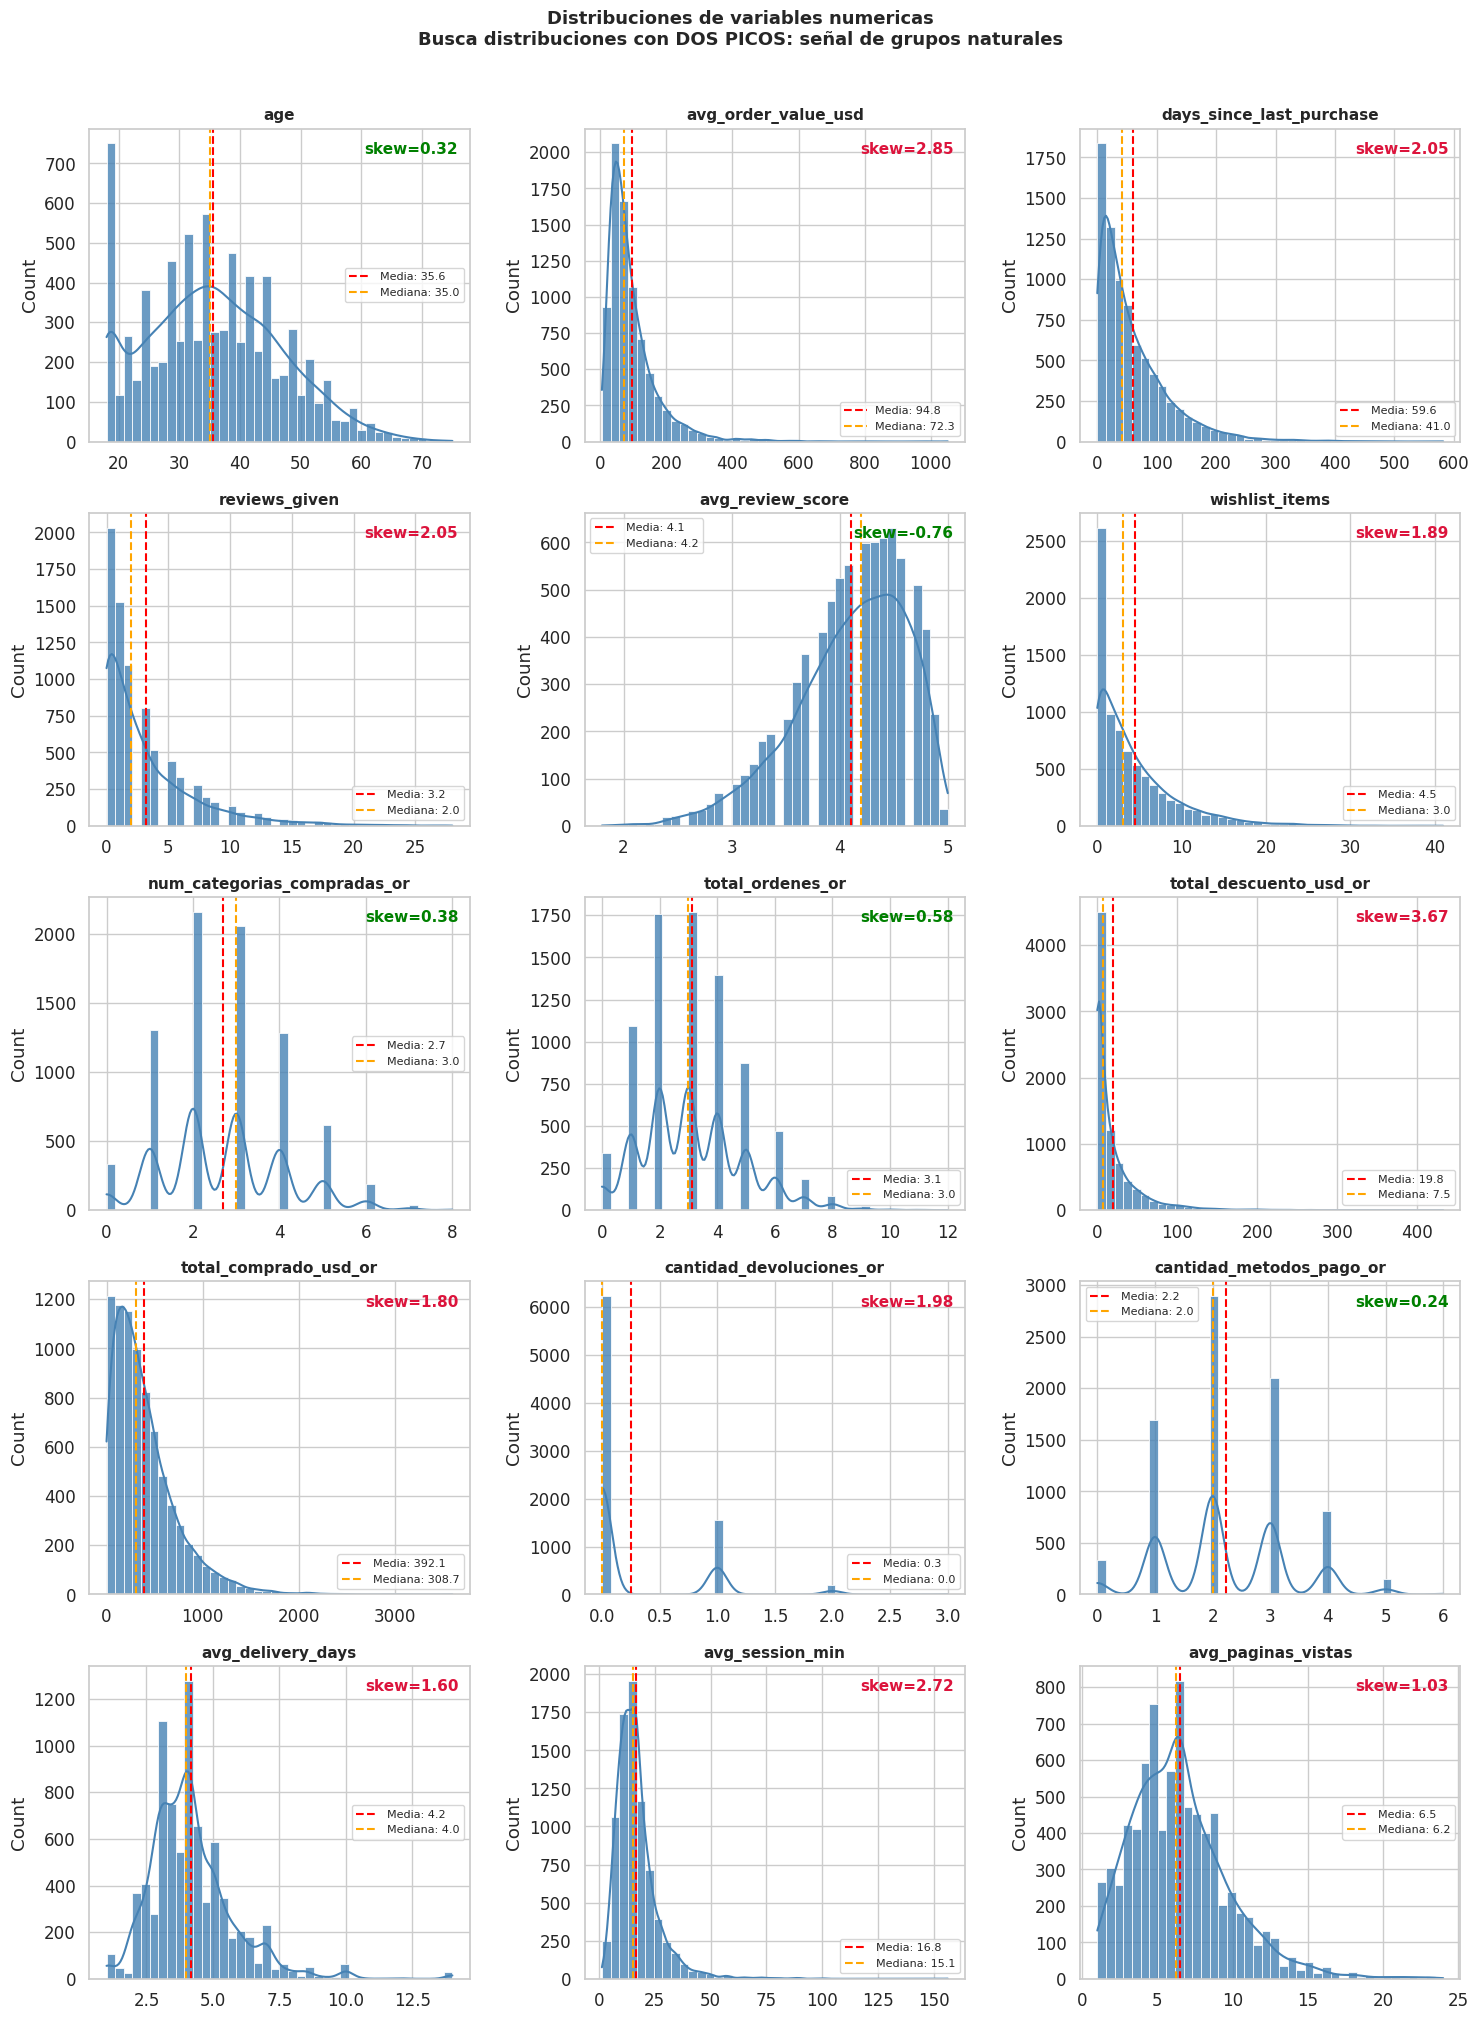

In [ ]:
print('Distribuciones con deteccion de multimodalidad ')
print('---------------------------------------------------')

ncols = 3
nrows = (len([col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in [ID_COL, TARGET_COL, *bin_cols]]) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data     = df[col].dropna()
    skew_val = data.skew()

    sns.histplot(data, ax=axes[i], kde=True, color='steelblue',
                 bins=40, edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(),   color='red',    ls='--', lw=1.5,
                    label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', ls='--', lw=1.5,
                    label=f'Mediana: {data.median():.1f}')

    color_skew = 'crimson' if abs(skew_val) > 1 else 'green'
    axes[i].annotate(f'skew={skew_val:.2f}',
                     xy=(0.97, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=11, color=color_skew, fontweight='bold')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Distribuciones de variables numericas\n'
    'Busca distribuciones con DOS PICOS: señal de grupos naturales',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()



- Se analizan las distribuciones de las variables numéricas mediante histogramas y métricas como la media, mediana y asimetría, con el fin de identificar posibles patrones, sesgos o multimodalidad. Como resultado, no se evidencia la presencia clara de grupos naturales en los datos.


In [ ]:
print('Diagnóstico de nulos')
print("-----------------------")

nulos = pd.DataFrame({
    'N nulos'    : df.isnull().sum(),
    '% nulos'    : (df.isnull().sum() / len(df) * 100).round(2),
    'tipo'       : df.dtypes
}).sort_values('% nulos', ascending=False)

nulos_reales = nulos[nulos['N nulos'] > 0]

if len(nulos_reales) == 0:
    print('Sin valores nulos.')
else:
    print(f'Columnas con nulos: {len(nulos_reales)}')
    display(
        nulos_reales.style
        .background_gradient(subset=['% nulos'], cmap='Reds')
        .format({'% nulos': '{:.1f}%'})
    )

Diagnóstico de nulos
-----------------------
Sin valores nulos.


- Se valida nuevamente que el tratamiento realizado nos garantice la ausencia de valores nulos.


# **4. TRANSFORMACIÓN Y ESCALAMIENTO (FEATURE ENGINEERING)**

**4.1. Tratamiento estadistico de valures atípicos (Outliers)**

En este paso del poryecto se realizara la indentificación de (Outlier) con el fin de gestionar datos extremos que pueden distorisionar el análisis, afectando métricas estadísticas y sesgar los resultados de los modelos.


In [ ]:
print("Detectar outliers con IQR ")
print("----------------------------------------------")

cols_num_clustering = [
    c for c in df.select_dtypes(include=['number', 'int64', 'float64']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
    and c not in date_cols
]

def calcular_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3,
        'Lím. inf': lim_inf, 'Lím. sup': lim_sup,
        'N outliers': n_out,
        '% outliers': round(n_out / len(serie) * 100, 2)
    })

tabla_out = (
    df[cols_num_clustering]
    .apply(lambda col: calcular_outliers_iqr(col.dropna()))
    .T.sort_values('% outliers', ascending=False)
)

tabla_out['impacto_KMeans'] = tabla_out['% outliers'].apply(
    lambda p: 'ALTO' if p > 5
         else 'MEDIO'    if p > 1
         else 'BAJO'
)

display(
    tabla_out.style
    .background_gradient(subset=['% outliers'], cmap='Reds')
    .map(
        lambda v: 'color: crimson; font-weight: bold' if 'ALTO' in str(v) else '',
        subset=['impacto_KMeans']
    )
    .format({'% outliers': '{:.1f}%', 'Q1': '{:.2f}', 'Q3': '{:.2f}',
             'Lím. inf': '{:.2f}', 'Lím. sup': '{:.2f}'})
)


Detectar outliers con IQR 
----------------------------------------------


,Q1,Q3,Lím. inf,Lím. sup,N outliers,% outliers,impacto_KMeans
cantidad_devoluciones_or,0.00,0.00,0.00,0.00,1780.000000,22.2%,ALTO
total_descuento_usd_or,0.00,25.64,-38.47,64.11,614.000000,7.7%,ALTO
wishlist_items,1.00,6.00,-6.50,13.50,478.000000,6.0%,ALTO
avg_order_value_usd,44.69,118.56,-66.12,229.37,477.000000,6.0%,ALTO
avg_session_min,10.75,20.00,-3.12,33.88,407.000000,5.1%,ALTO
days_since_last_purchase,16.00,84.00,-86.00,186.00,351.000000,4.4%,MEDIO
total_comprado_usd_or,151.21,537.22,-427.80,1116.23,328.000000,4.1%,MEDIO
reviews_given,0.00,5.00,-7.50,12.50,302.000000,3.8%,MEDIO
avg_paginas_vistas,4.00,8.20,-2.30,14.50,196.000000,2.5%,MEDIO
avg_delivery_days,3.00,5.00,0.00,8.00,183.000000,2.3%,MEDIO


- Se aplica el método del rango intercuartílico (IQR) para detectar valores atípicos en las variables numéricas, con el fin de cuantificar su presencia y evaluar su posible impacto en el modelo de clustering.
Como resultado, se identifican variables con distintos niveles de afectación (bajo, medio y alto), lo que permite priorizar su tratamiento, especialmente en modelos como K-Means que son sensibles a valores extremos.


Visualizar outliers con box plot
----------------------------------------------


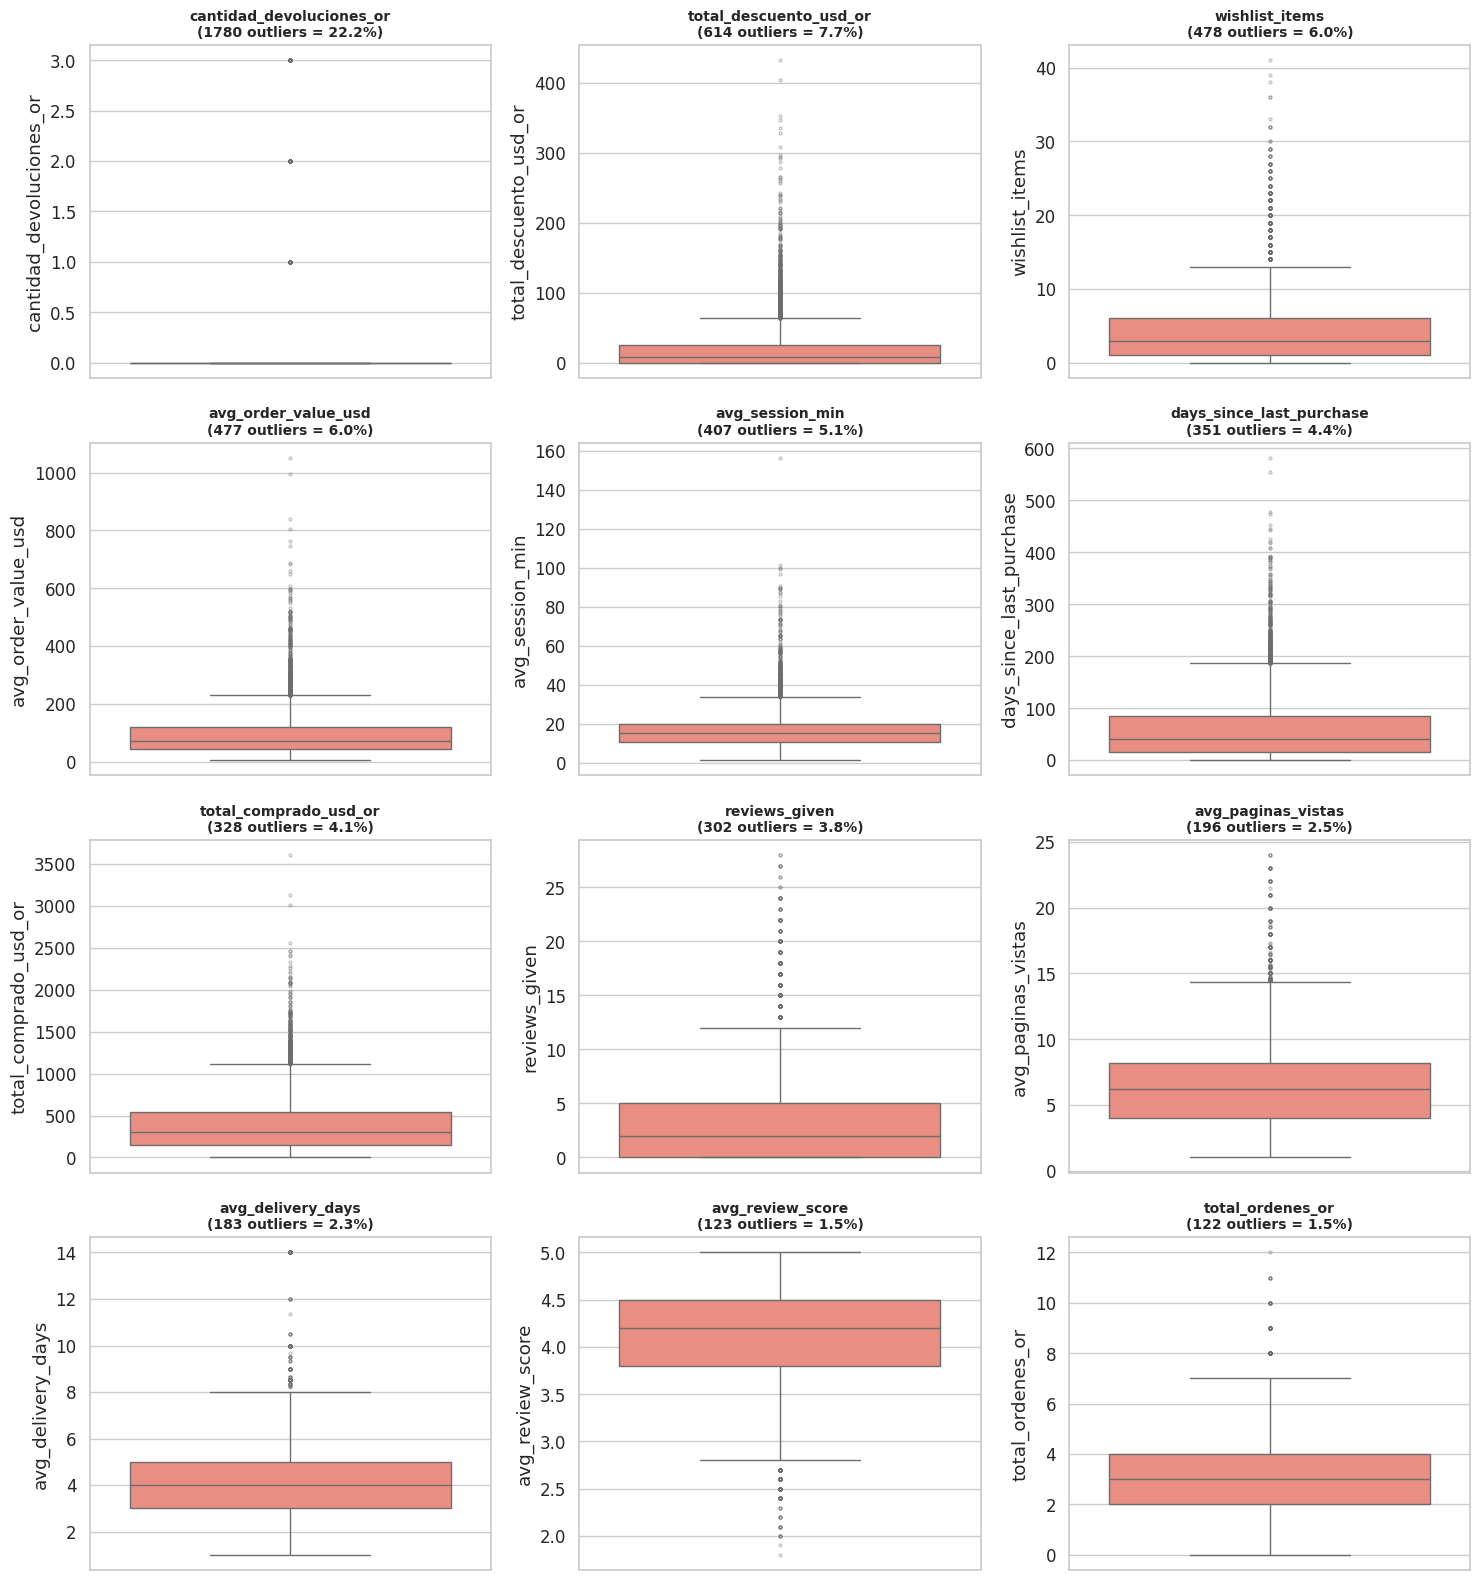

In [ ]:
print('Visualizar outliers con box plot')
print("----------------------------------------------")

cols_con_out = tabla_out[tabla_out['% outliers'] > 1].index.tolist()

if cols_con_out:
    ncols = min(3, len(cols_con_out))
    nrows = (len(cols_con_out) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_con_out):
        sns.boxplot(y=df[col].dropna(), ax=axes[i],
                    color='salmon',
                    flierprops=dict(marker='.', color='crimson',
                                   alpha=0.4, markersize=4))
        n_out = int(tabla_out.loc[col, 'N outliers'])
        pct   = tabla_out.loc[col, '% outliers']
        axes[i].set_title(f'{col}\n({n_out} outliers = {pct:.1f}%)',
                          fontweight='bold', fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('Sin outliers significativos (> 1%). Continuamos.')


In [ ]:
cols_log = [
    'cantidad_devoluciones_or',
    'total_descuento_usd_or',
    'total_comprado_usd_or',
    'total_ordenes_or'
]

for col in cols_log:
    df[col] = np.log1p(df[col].clip(lower=0))


- Usaremos la version logaritmica de estas variables para el clustering, ya que el log ayuda a reducir el impacto de los valores extremos y a acercar la distribucion a una forma mas simetrica, lo que mejora el rendimiento de KMeans.

In [ ]:
cols_winsor = ['avg_order_value_usd', 'avg_session_min', 'wishlist_items']

for col in cols_winsor:
    df[col] = winsorize(df[col], limits=[0.01, 0.99])

cols_winsor_soft = [
    'days_since_last_purchase',
    'reviews_given',
    'avg_paginas_vistas',
    'avg_delivery_days',
    'avg_review_score'
]

for col in cols_winsor_soft:
    df[col] = winsorize(df[col], limits=[0.005, 0.995])


- Usaremos la version winsorizada de estas variables para el clustering, ya que el winsorize limita el impacto de los outliers extremos sin eliminar completamente la información de comportamiento que aportan, lo que puede mejorar la estabilidad de los centroides de KMeans.

In [ ]:
print("Versión Final luego de tratar los outliers")
print("----------------------------------------------")

cols_num_clustering = [
    c for c in df.select_dtypes(include=['number', 'int64', 'float64']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
    and c not in date_cols
]

def calcular_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3,
        'Lím. inf': lim_inf, 'Lím. sup': lim_sup,
        'N outliers': n_out,
        '% outliers': round(n_out / len(serie) * 100, 2)
    })

tabla_out = (
    df[cols_num_clustering]
    .apply(lambda col: calcular_outliers_iqr(col.dropna()))
    .T.sort_values('% outliers', ascending=False)
)

tabla_out['impacto_KMeans'] = tabla_out['% outliers'].apply(
    lambda p: 'ALTO' if p > 5
         else 'MEDIO'    if p > 1
         else 'BAJO'
)

display(
    tabla_out.style
    .background_gradient(subset=['% outliers'], cmap='Reds')
    .map(
        lambda v: 'color: crimson; font-weight: bold' if 'ALTO' in str(v) else '',
        subset=['impacto_KMeans']
    )
    .format({'% outliers': '{:.1f}%', 'Q1': '{:.2f}', 'Q3': '{:.2f}',
             'Lím. inf': '{:.2f}', 'Lím. sup': '{:.2f}'})
)

Versión Final luego de tratar los outliers
----------------------------------------------


,Q1,Q3,Lím. inf,Lím. sup,N outliers,% outliers,impacto_KMeans
cantidad_devoluciones_or,0.00,0.00,0.00,0.00,1780.000000,22.2%,ALTO
total_comprado_usd_or,5.03,6.29,3.13,8.18,407.000000,5.1%,ALTO
total_ordenes_or,1.10,1.61,0.33,2.38,350.000000,4.4%,MEDIO
age,27.00,43.00,3.00,67.00,23.000000,0.3%,BAJO
num_categorias_compradas_or,2.00,4.00,-1.00,7.00,10.000000,0.1%,BAJO
days_since_last_purchase,0.00,0.00,0.00,0.00,0.000000,0.0%,BAJO
avg_order_value_usd,13.78,13.78,13.78,13.78,0.000000,0.0%,BAJO
wishlist_items,0.00,0.00,0.00,0.00,0.000000,0.0%,BAJO
avg_review_score,2.50,2.50,2.50,2.50,0.000000,0.0%,BAJO
reviews_given,0.00,0.00,0.00,0.00,0.000000,0.0%,BAJO


- Se realiza una verificación final de (Outlier) despúes de su tratamiento con el fin de verificar la reducción de valores atípicos y su impacto en las variables, evidenciando una disminución del porcentaje en la gran mayoria de variables reduciendo el impacto del modelo, mejorando calidad y estabilidad de los datos para el análisis.

**4.2 Análisis de variables categoricas**

Se analizan las distribuciones de las variables categóricas mediante frecuencias y porcentajes, con el fin de identificar el nivel de dominancia de sus categorías. Esto permite evaluar su relevancia en el clustering, ya que variables altamente dominadas por una sola categoría pueden aportar poca capacidad de segmentación.

Frecuencias y distribucion de variables categoricas
---------------------------------------------------


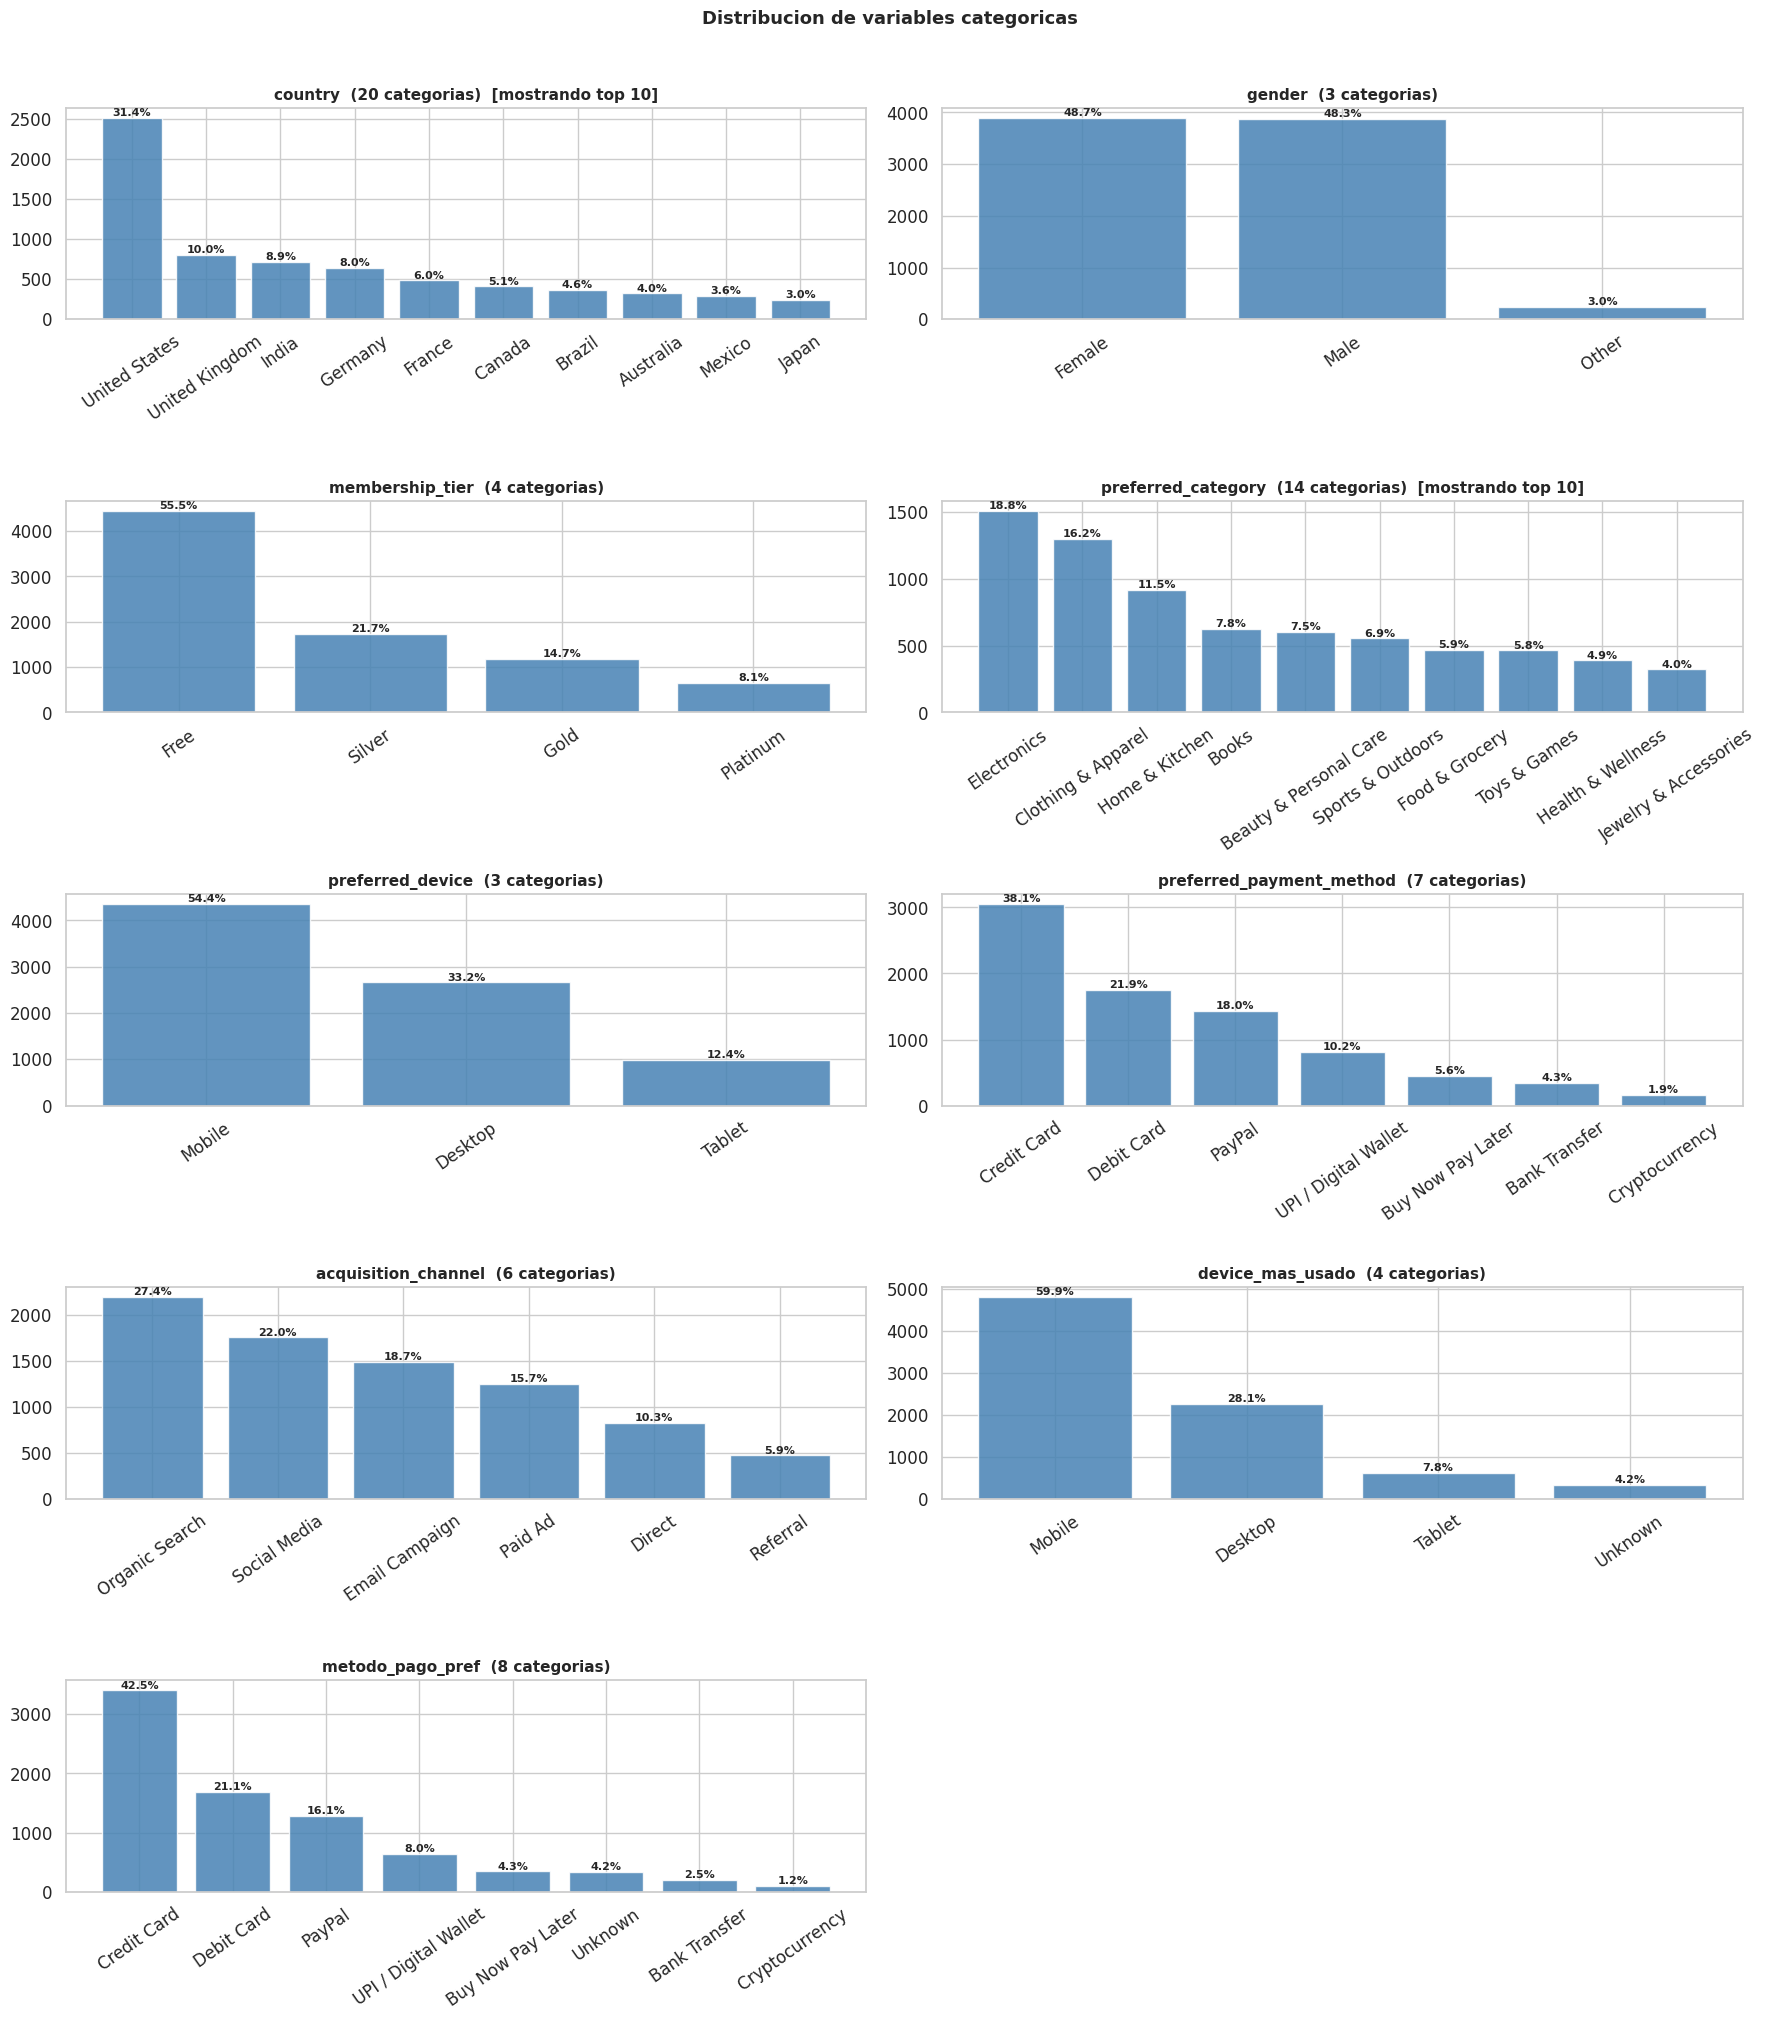

DIAGNOSTICO DE DOMINANCIA (% de la categoria mas frecuente):
-----------------------------------------------------------------
  country                             top="United States" (31.4%)  Bien distribuida -> buena candidata
  gender                              top="Female" (48.7%)  Bien distribuida -> buena candidata
  membership_tier                     top="Free" (55.5%)  Dominancia moderada -> util con cuidado
  preferred_category                  top="Electronics" (18.8%)  Bien distribuida -> buena candidata
  preferred_device                    top="Mobile" (54.4%)  Dominancia moderada -> util con cuidado
  preferred_payment_method            top="Credit Card" (38.1%)  Bien distribuida -> buena candidata
  acquisition_channel                 top="Organic Search" (27.4%)  Bien distribuida -> buena candidata
  device_mas_usado                    top="Mobile" (59.9%)  Dominancia moderada -> util con cuidado
  metodo_pago_pref                    top="Credit Card" (42.5%)  Bien 

In [ ]:
print('Frecuencias y distribucion de variables categoricas')
print("---------------------------------------------------")

ncols = 2
nrows = (len(cat_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 9, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100


    top_n = 10
    vc_plot  = vc.head(top_n)
    pct_plot = pct.head(top_n)

    bars = axes[i].bar(vc_plot.index, vc_plot.values,
                       color='steelblue', edgecolor='white', alpha=0.85)
    for bar, p in zip(bars, pct_plot.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vc_plot)*0.01,
                     f'{p:.1f}%', ha='center', fontsize=8, fontweight='bold')
    titulo = f'{col}  ({df[col].nunique()} categorias)'
    if df[col].nunique() > top_n:
        titulo += f'  [mostrando top {top_n}]'
    axes[i].set_title(titulo, fontweight='bold', fontsize=11)
    axes[i].tick_params(axis='x', rotation=35)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de variables categoricas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Diagnostico de dominancia
print('DIAGNOSTICO DE DOMINANCIA (% de la categoria mas frecuente):')
print('-' * 65)
for col in cat_cols:
    dom  = df[col].value_counts(normalize=True).iloc[0] * 100
    top1 = df[col].value_counts().index[0]
    if dom > 70:
        diag = f'DOMINANCIA ALTA  -> evaluar si aporta al clustering'
    elif dom > 50:
        diag = f'Dominancia moderada -> util con cuidado'
    else:
        diag = f'Bien distribuida -> buena candidata'
    print(f'  {col:<35} top="{top1}" ({dom:.1f}%)  {diag}')


- La mayoría de las variables categóricas presentan una distribución equilibrada, lo que indica una baja dominancia de una sola categoría. En general, estas variables aportan valor al proceso de segmentación, ya que permiten diferenciar grupos de clientes con comportamientos distintos.

**4.3. Trasnformación de variables categoricas**

K-Means es un algoritmo matemático basado en distancias (Euclidiana), por lo que no comprende texto.

El OHE permite convertir preferencias en vectores binarios de ausencia/presencia (0 y 1) sin asumir que una categoría vale más que otra.

El Label Encoding se justificó en la variable membership_tier porque es una variable ordinal (existe una jerarquía clara: Free < Silver < Gold < Platinum).

In [ ]:
df_categoricas_interpretacion = pd.DataFrame()

cols_cat_actual = [
    c for c in df.select_dtypes(include=['object','category', 'string']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
]

print(f'Variables categóricas detectadas: {len(cols_cat_actual)}')
print()
for col in cols_cat_actual:
    n_uniq = df[col].nunique()
    top5   = df[col].value_counts().head(5).index.tolist()
    print(f'   {col:<30} {n_uniq:>3} categorías  top5: {top5}')

print()
print(list(cols_cat_actual))

Variables categóricas detectadas: 9

   country                         20 categorías  top5: ['United States', 'United Kingdom', 'India', 'Germany', 'France']
   gender                           3 categorías  top5: ['Female', 'Male', 'Other']
   membership_tier                  4 categorías  top5: ['Free', 'Silver', 'Gold', 'Platinum']
   preferred_category              14 categorías  top5: ['Electronics', 'Clothing & Apparel', 'Home & Kitchen', 'Books', 'Beauty & Personal Care']
   preferred_device                 3 categorías  top5: ['Mobile', 'Desktop', 'Tablet']
   preferred_payment_method         7 categorías  top5: ['Credit Card', 'Debit Card', 'PayPal', 'UPI / Digital Wallet', 'Buy Now Pay Later']
   acquisition_channel              6 categorías  top5: ['Organic Search', 'Social Media', 'Email Campaign', 'Paid Ad', 'Direct']
   device_mas_usado                 4 categorías  top5: ['Mobile', 'Desktop', 'Tablet', 'Unknown']
   metodo_pago_pref                 8 categorías  top5: [

In [ ]:
print('Se genera tratamiento a las columnas categoricas del Df')
print("---------------------------------------------------")

print('Excluir categóricas (usar solo para interpretar después del clustering)')

cols_cat_actual_eliminar = ['country']

df_categoricas_interpretacion = df[cols_cat_actual_eliminar + (
    [TARGET_COL] if TARGET_COL and TARGET_COL in df.columns else []
)].copy()

df = df.drop(columns=df_categoricas_interpretacion)
print('categóricas excluidas del clustering.')
print(f'Guardadas en df_categoricas_interpretacion: {df_categoricas_interpretacion.shape}')
print()
print('---------------------------------------------------')

print('OHE e incluir')
print('---------------------------------------------------')


cols_para_ohe = ['gender', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel']  # <-- CAMBIA
if cols_para_ohe:
    df = pd.get_dummies(df, columns=cols_para_ohe, drop_first=False, dtype=int)
    print(f'OHE aplicado a: {cols_para_ohe}')
    print(f'Shape después del OHE: {df.shape}')
print('---------------------------------------------------')


print('Label Encoding para ordinales')
print('---------------------------------------------------')

cols_ordinales = {
    'membership_tier': ['Free', 'Silver', 'Gold', 'Platinum'],
}
for col, orden in cols_ordinales.items():
    if col in df.columns:
        mapeo = {cat: i for i, cat in enumerate(orden)}
        df[col] = df[col].map(mapeo)
        print(f'Label Encoding ordinal: {col} -> {mapeo}')

Se genera tratamiento a las columnas categoricas del Df
---------------------------------------------------
Excluir categóricas (usar solo para interpretar después del clustering)
categóricas excluidas del clustering.
Guardadas en df_categoricas_interpretacion: (8000, 2)

---------------------------------------------------
OHE e incluir
---------------------------------------------------
OHE aplicado a: ['gender', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel']
Shape después del OHE: (8000, 53)
---------------------------------------------------
Label Encoding para ordinales
---------------------------------------------------
Label Encoding ordinal: membership_tier -> {'Free': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}


**4.4. Creación y eliminación de variables nuevas**

Este paso nos permite enriqueser la información disponible, capturando patrones y relaciones que no son evidentes en las variables originales, lo que mejora el desempeño y segmentacion de los moedelos.

In [ ]:
print('segmentacion de la columnas de fecha')
print("----------------------------------------------")

fecha_referencia = pd.Timestamp.today()

for col in date_cols:
    if col not in df.columns:
        continue
    nombre_antiguedad = f'{col}_antiguedad_dias'
    df[nombre_antiguedad] = (fecha_referencia - df[col]).dt.days

    mediana_dias = df[nombre_antiguedad].median()
    df[nombre_antiguedad] = df[nombre_antiguedad].fillna(mediana_dias)

    df = df.drop(columns=[col])
    print(f'Creada: {nombre_antiguedad}')
    print(f'   Min: {df[nombre_antiguedad].min():.0f} días')
    print(f'   Max: {df[nombre_antiguedad].max():.0f} días')
    print(f'   Media: {df[nombre_antiguedad].mean():.0f} días')
    print(f'Eliminada: {col}')

if not date_cols:
    print('No hay columnas de fecha configuradas. Paso omitido.')

segmentacion de la columnas de fecha
----------------------------------------------
Creada: registration_date_antiguedad_dias
   Min: 47 días
   Max: 5402 días
   Media: 638 días
Eliminada: registration_date


- Se transforman las variables de fecha en métricas de antigüedad en días, con el fin de convertir la información temporal en variables numéricas útiles para el análisis. Esto permite capturar el comportamiento en el tiempo y facilita su uso en modelos de clustering. Adicionalmente, se imputan valores faltantes con la mediana para evitar pérdida de información.

In [ ]:
print('Eliminar features quasi-constantes (varianza casi nula)')
print("----------------------------------------------")


cols_para_clustering = [
    c for c in df.select_dtypes(include=['number', 'float64', 'int64']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
]

UMBRAL_VARIANZA = 0.01
vt = VarianceThreshold(threshold=UMBRAL_VARIANZA)
vt.fit(df[cols_para_clustering])

cols_baja_varianza = [
    col for col, support in zip(cols_para_clustering, vt.get_support())
    if not support
]

if cols_baja_varianza:
    print(f'Columnas con varianza < {UMBRAL_VARIANZA} (quasi-constantes):')
    for col in cols_baja_varianza:
        print(f'   {col:<30} varianza = {df[col].var():.6f}')
    print()
    print('estas columnas se eliminarán.')
else:
    print(f'Sin features quasi-constantes (umbral varianza: {UMBRAL_VARIANZA}).')
    print('Todas las features tienen varianza suficiente.')

Eliminar features quasi-constantes (varianza casi nula)
----------------------------------------------
Columnas con varianza < 0.01 (quasi-constantes):
   avg_order_value_usd            varianza = 0.000000
   days_since_last_purchase       varianza = 0.000000
   reviews_given                  varianza = 0.000000
   avg_review_score               varianza = 0.000000
   wishlist_items                 varianza = 0.000000
   avg_delivery_days              varianza = 0.000000
   avg_session_min                varianza = 0.000000
   avg_paginas_vistas             varianza = 0.000000

estas columnas se eliminarán.


In [ ]:
print('Eliminando columnas con Varianza casi nula')
print('--------------------------------------------\n')

columnas_importantes = ['days_since_last_purchase']
if columnas_importantes:
    print(f'Columnas de baja varianza que se conservarán por justificación de negocio: {columnas_importantes}\n')
    for col in columnas_importantes:
        cols_baja_varianza.remove(col)
df = df.drop(columns=cols_baja_varianza)
print(f'Eliminadas: {cols_baja_varianza}')

Eliminando columnas con Varianza casi nula
--------------------------------------------

Columnas de baja varianza que se conservarán por justificación de negocio: ['days_since_last_purchase']

Eliminadas: ['avg_order_value_usd', 'reviews_given', 'avg_review_score', 'wishlist_items', 'avg_delivery_days', 'avg_session_min', 'avg_paginas_vistas']


- Se identifican y eliminan las variables con varianza casi nula (quasi-constantes), ya que no aportan capacidad de diferenciación entre observaciones. Esto permite reducir el ruido en los datos, mejorar la eficiencia del modelo y favorecer una segmentación más clara.

In [ ]:
print('features altamente correlacionadas')
print("------------------------------------")

UMBRAL_CORRELACION = 0.85

cols_para_clustering = [
    c for c in df.select_dtypes(include='number').columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
]

corr_matrix = df[cols_para_clustering].corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pares_alta_corr = [
    (c1, c2, upper.loc[c1, c2])
    for c1 in upper.columns for c2 in upper.columns
    if pd.notna(upper.loc[c1, c2]) and upper.loc[c1, c2] > UMBRAL_CORRELACION
]

if pares_alta_corr:
    print(f'Pares con correlación > {UMBRAL_CORRELACION}:')
    print()
    cols_a_eliminar_corr = set()
    for c1, c2, r in sorted(pares_alta_corr, key=lambda x: -x[2]):
        var_c1 = df[c1].var()
        var_c2 = df[c2].var()

        eliminar = c1 if var_c1 < var_c2 else c2
        conservar = c2 if var_c1 < var_c2 else c1
        cols_a_eliminar_corr.add(eliminar)
        print(f'   r={r:.3f}  {c1} <-> {c2}')
        print(f'          -> Conservar: {conservar} (mayor varianza)')
        print(f'          -> Eliminar : {eliminar} (menor varianza)')
        print()

    print()
    print(f'Columnas a eliminar: {cols_a_eliminar_corr}')
else:
    print(f'Sin correlaciones críticas (> {UMBRAL_CORRELACION}).')
    print('Todas las features aportan información independiente.')

features altamente correlacionadas
------------------------------------
Pares con correlación > 0.85:

   r=0.942  gender_Female <-> gender_Male
          -> Conservar: gender_Female (mayor varianza)
          -> Eliminar : gender_Male (menor varianza)

   r=0.906  num_categorias_compradas_or <-> total_ordenes_or
          -> Conservar: num_categorias_compradas_or (mayor varianza)
          -> Eliminar : total_ordenes_or (menor varianza)


Columnas a eliminar: {'total_ordenes_or', 'gender_Male'}


In [ ]:
print('Eliminando columnas altamente correlacionadas...')
cols_a_eliminar_corr = ['gender_Male', 'num_categorias_compradas_or', 'gender_Other']
df = df.drop(columns=list(cols_a_eliminar_corr))
print(f'Eliminadas: {cols_a_eliminar_corr}')
print(f'Shape después: {df.shape}')

Eliminando columnas altamente correlacionadas...
Eliminadas: ['gender_Male', 'num_categorias_compradas_or', 'gender_Other']
Shape después: (8000, 43)


- Se identifican variables altamente correlacionadas para evitar redundancia en la información, ya que aportan datos similares. Se eliminan aquellas con menor varianza, conservando las más representativas, lo que mejora la eficiencia del modelo y evita sesgos en el clustering.

**4.5. Escalamiento de magnitudes**

Las variables numéricas tenían magnitudes totalmente distintas (ej. Edad ronda los 30-50, pero el gasto total ronda los miles de dólares). Sin escalamiento, el K-Means le daría una importancia desproporcionada a la variable con números más grandes. Se eligió RobustScaler porque es excelente manejando conjuntos de datos que, incluso tras limpiezas previas, mantienen colas de datos (outliers marginales), usando la mediana y el rango intercuartílico.


In [ ]:
print('Identificar columnas para escalar')
print("--------------------------------------------------------------------------------------------------------------")

cols_escalar = [
    c for c in df.select_dtypes(include=['number', 'float64', 'int64']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
    and df[c].nunique() > 2
]

cols_binarias = [
    c for c in df.select_dtypes(include=['number', 'float64', 'int64']).columns
    if c not in ([ID_COL] if ID_COL else [])
    and c not in ([TARGET_COL] if TARGET_COL else [])
    and df[c].nunique() == 2
]

print(f'Columnas a escalar  ({len(cols_escalar)}): {cols_escalar}')
print(f'Columnas binarias   ({len(cols_binarias)}): {cols_binarias} <- no se escalan')
print()


Identificar columnas para escalar
--------------------------------------------------------------------------------------------------------------
Columnas a escalar  (8): ['age', 'membership_tier', 'total_ordenes_or', 'total_descuento_usd_or', 'total_comprado_usd_or', 'cantidad_devoluciones_or', 'cantidad_metodos_pago_or', 'registration_date_antiguedad_dias']
Columnas binarias   (31): ['gender_Female', 'preferred_category_Automotive', 'preferred_category_Beauty & Personal Care', 'preferred_category_Books', 'preferred_category_Clothing & Apparel', 'preferred_category_Electronics', 'preferred_category_Food & Grocery', 'preferred_category_Health & Wellness', 'preferred_category_Home & Kitchen', 'preferred_category_Jewelry & Accessories', 'preferred_category_Office Supplies', 'preferred_category_Pet Supplies', 'preferred_category_Sports & Outdoors', 'preferred_category_Toys & Games', 'preferred_category_Travel & Luggage', 'preferred_device_Desktop', 'preferred_device_Mobile', 'preferred_dev

In [ ]:
print('Escalar variables numéricas para clustering')
print("---------------------------------------------")

escalador = RobustScaler()

df_cluster_original = df.copy()

df_scaled             = df.copy()
df_scaled[cols_escalar] = escalador.fit_transform(df[cols_escalar])

print(f'Escalador aplicado: {type(escalador).__name__}')
print(f'Columnas escaladas : {len(cols_escalar)}')

Escalar variables numéricas para clustering
---------------------------------------------
Escalador aplicado: RobustScaler
Columnas escaladas : 8


- Aplicamos este escaladro para reducir el impacto de los outliers que conservamos en algunas variables, y para llevar todas las variables numéricas a una escala comparable, lo que mejora el rendimiento de KMeans.')

Comparación visual antes vs después
--------------------------------------


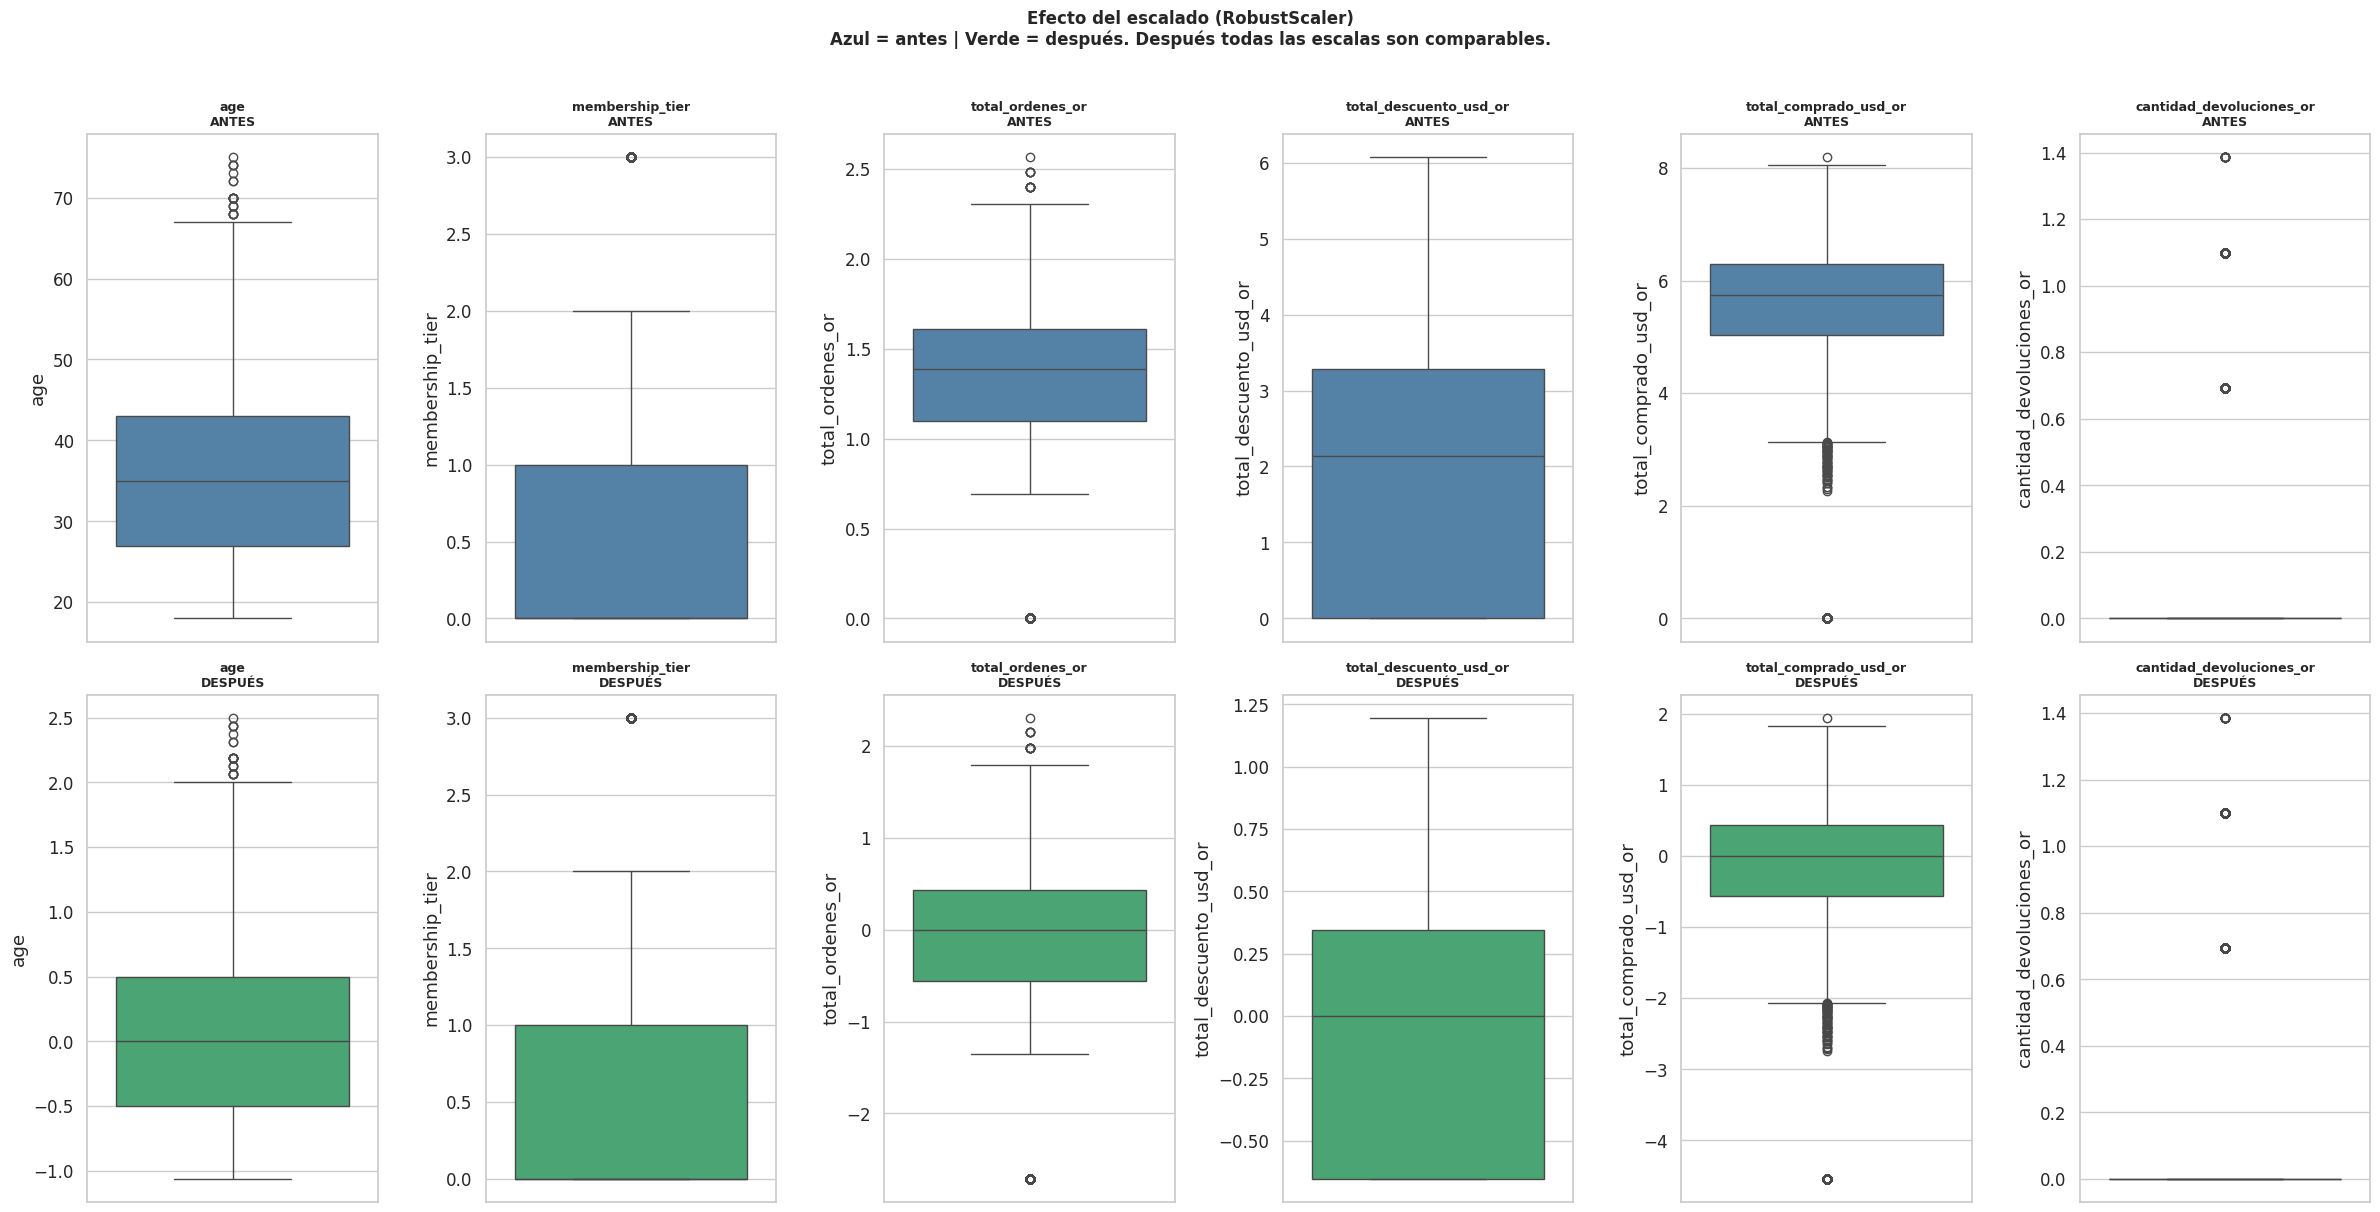

In [ ]:
print('Comparación visual antes vs después')
print("--------------------------------------")
n = min(6, len(cols_escalar))
fig, axes = plt.subplots(2, n, figsize=(n * 4, 12))

for i, col in enumerate(cols_escalar[:n]):
    sns.boxplot(y=df[col],          ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col}\nANTES', fontweight='bold', fontsize=9)

    sns.boxplot(y=df_scaled[col],   ax=axes[1, i], color='mediumseagreen')
    axes[1, i].set_title(f'{col}\nDESPUÉS', fontweight='bold', fontsize=9)

fig.suptitle(
    f'Efecto del escalado ({type(escalador).__name__})\n'
    'Azul = antes | Verde = después. Después todas las escalas son comparables.',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

**4.6. Matriz final para el modelado**

Aqui garantizamos que la entrada que recibira el algoritmo en la siguiente fase cumpla al 100% con las restricciones matemáticas, separando un Dataser limpio de 8.000 registros por 40 categorias.

In [ ]:
sep  = '-' * 65
sep2 = '=' * 65

df_final = df_scaled.copy()

# Excluir columna de validación si existe
if TARGET_COL and TARGET_COL in df_final.columns:
    y_validacion = df_final[TARGET_COL].copy()
    df_final = df_final.drop(columns=[TARGET_COL])
else:
    y_validacion = None

# Excluir ID si existe
if ID_COL and ID_COL in df_final.columns:
    df_final = df_final.drop(columns=[ID_COL])

# Drop remaining object type columns that were not encoded for clustering
object_cols_to_drop = df_final.select_dtypes(include='object').columns.tolist()
if object_cols_to_drop:
    print(f"Dropping non-numeric columns: {object_cols_to_drop}")
    df_final = df_final.drop(columns=object_cols_to_drop)


print(sep2)
print('  CHECKLIST — DATASET LISTO PARA CLUSTERING')
print(sep2)

checks = []

# Check 1: Sin nulos
n_nulos = df_final.isnull().sum().sum()
estado  = 'OK' if n_nulos == 0 else f'ALERTA — {n_nulos} nulos (volver al Paso 3)'
checks.append(('Sin valores nulos', estado))

# Check 2: Sin columnas de texto
cols_texto = df_final.select_dtypes(include='object').columns.tolist()
estado = 'OK' if len(cols_texto) == 0 else f'ALERTA — columnas texto: {cols_texto} (volver al Paso 6)'
checks.append(('Sin columnas de texto', estado))

# Check 3: Sin identificadores
estado = 'OK' if (ID_COL not in df_final.columns) else f'ALERTA — {ID_COL} sigue en el dataset'
checks.append(('Identificador excluido', estado))

# Check 4: Sin target/validación
estado = 'OK' if (TARGET_COL not in df_final.columns or TARGET_COL is None) else 'ALERTA — target sigue en el dataset'
checks.append(('Variable de target excluida', estado))

# Check 5: Varianza suficiente
varianzas_bajas = [c for c in df_final.columns if df_final[c].var() < 0.001]
estado = 'OK' if len(varianzas_bajas) == 0 else f'ALERTA — {varianzas_bajas} (volver al Paso 7a)'
checks.append(('Sin features quasi-constantes', estado))

# Check 6: Correlaciones
corr_max = df_final.corr().abs().where(
    np.triu(np.ones(df_final.corr().shape), k=1).astype(bool)
).max().max()
estado = 'OK' if corr_max < 0.85 else f'ALERTA — correlación máxima = {corr_max:.3f} (volver al Paso 7b)'
checks.append(('Sin correlaciones extremas (< 0.85)', estado))

# Check 7: Todas numéricas
n_numericas = df_final.select_dtypes(include='number').shape[1]
estado = 'OK' if n_numericas == df_final.shape[1] else f'ALERTA — hay {df_final.shape[1] - n_numericas} no numéricas'
checks.append(('Todas las columnas son numéricas', estado))

# Imprimir resultados
print()
for nombre, estado in checks:
    icono = 'OK' if estado == 'OK' else 'ALERTA'
    print(f'   [{icono}]  {nombre:<40} {estado}')

print()
print(sep)
print(f'  Shape final del dataset para clustering: {df_final.shape}')
print(f'  Features: {df_final.columns.tolist()}')
if y_validacion is not None:
    print(f'  Variable de validación guardada: {TARGET_COL} ({y_validacion.shape[0]} registros)')
print(sep2)
print()
n_alertas = sum(1 for _, e in checks if e != 'OK')
if n_alertas == 0:
    print('  Dataset listo. Continúa con el módulo C3 (KMeans).')
else:
    print(f'  {n_alertas} ALERTA(s) detectada(s). Vuelve al paso indicado antes de continuar.')
print(sep2)

Dropping non-numeric columns: ['device_mas_usado', 'metodo_pago_pref']
  CHECKLIST — DATASET LISTO PARA CLUSTERING

   [OK]  Sin valores nulos                        OK
   [OK]  Sin columnas de texto                    OK
   [OK]  Identificador excluido                   OK
   [OK]  Variable de target excluida              OK
   [ALERTA]  Sin features quasi-constantes            ALERTA — ['days_since_last_purchase'] (volver al Paso 7a)
   [OK]  Sin correlaciones extremas (< 0.85)      OK
   [OK]  Todas las columnas son numéricas         OK

-----------------------------------------------------------------
  Shape final del dataset para clustering: (8000, 40)
  Features: ['age', 'membership_tier', 'days_since_last_purchase', 'total_ordenes_or', 'total_descuento_usd_or', 'total_comprado_usd_or', 'cantidad_devoluciones_or', 'cantidad_metodos_pago_or', 'gender_Female', 'preferred_category_Automotive', 'preferred_category_Beauty & Personal Care', 'preferred_category_Books', 'preferred_categ


**4.7. Preparar Datasets Finales para Modelado**

Antes de entrenar el algoritmo, es una mejor práctica en Clustering dividir la información en diferentes matrices según su propósito. Un modelo K-Means requiere datos numéricos y escalados, pero el análisis de negocio posterior requiere los valores reales y las categorías.

In [ ]:


# Dataset escalado (para los algoritmos)
df_para_modelado = df_final.copy()
if ID_COL and ID_COL in df_para_modelado.columns:
    df_para_modelado = df_para_modelado.drop(columns=[ID_COL])

# Dataset original sin escalar (para interpretar)
df_cluster_original_comparar = df_cluster_original.copy()
if ID_COL and ID_COL in df_cluster_original_comparar.columns:
    df_cluster_original_comparar = df_cluster_original_comparar.drop(columns=[ID_COL])
if TARGET_COL and TARGET_COL in df_cluster_original_comparar.columns:
    df_cluster_original_comparar = df_cluster_original_comparar.drop(columns=[TARGET_COL])

# Excluir categóricas que fueron separadas
cols_a_excluir_orig = [c for c in df_cluster_original_comparar.columns
                        if c in df_categoricas_interpretacion.columns
                        and c not in [ID_COL, TARGET_COL]]
if cols_a_excluir_orig:
    df_cluster_original_comparar = df_cluster_original_comparar.drop(columns=cols_a_excluir_orig, errors='ignore')
df_cluster_original_copia = df_cluster_original_comparar.copy()

# Variable de validación
if y_validacion is not None:
    df_y_validacion = y_validacion.to_frame().copy()

# Categóricas para interpretación
df_categoricas_interpretacion_copia = df_categoricas_interpretacion.copy()



- Se crearon las siguientes particiones justificadas analíticamente:

| Dataset / Variable | Acción en el Código | Justificación Analítica y de Negocio |
| :--- | :--- | :--- |
| **`df_para_modelado`** | Se aísla la matriz escalada y se elimina el `customer_id`. | **Input del Modelo:** Es la matriz matemática pura. Se elimina el ID para evitar que el algoritmo intente calcular "distancias" utilizando un número de identificación. |
| **`df_cluster_original_copia`** | Se guarda una copia de los datos numéricos antes del escalado (`RobustScaler`). | **Perfilamiento:** Los centroides del modelo estarán escalados. Se necesita esta base original para traducir los grupos a valores reales de negocio (ej. "Gastan $500" en lugar de "Z-score de 1.2"). |
| **`df_y_validacion`** | Se separa la variable `churned` (Abandono). | **Validación Externa:** El Clustering no sabe quién abandonó la plataforma. Al separar esta variable, podremos cruzarla después con los clústeres para ver si el modelo logró agrupar naturalmente a los desertores. |
| **`df_categoricas_interpretacion`**| Se aíslan las variables demográficas (País, categoría, etc.). | **Enriquecimiento:** Se usarán al finalizar el proyecto para darle "personalidad" a los clústeres (ej. descubrir si el *Clúster Premium* prefiere comprar desde el móvil o usar tarjeta de crédito). |


# **5.SELECCIÓN DE VARIABLES Y BÚSQUEDA DEL JK ÓPTIMO**

Con el dataset escalado listo, el siguiente paso es determinar con cuántos grupos (k) trabajará el modelo. Antes de eso, seleccionamos únicamente las variables de comportamiento transaccional y RFM, dejando por fuera las dummies OHE que distorsionan las distancias euclidianas de K-Means sin aportar separación real entre perfiles de compra.

Para elegir el k usamos dos criterios simultáneamente:
- **Método del Codo:** evalúa la inercia. Buscamos el punto donde la curva deja de bajar bruscamente.
- **Coeficiente de Silueta:** mide qué tan bien separados quedan los clusters. Rango de -1 a 1, mientras más cercano a 1 mejor.

Para elegir el k usamos dos criterios simultáneamente:
- **Método del Codo:** evalúa la inercia. Buscamos el punto donde la curva deja de bajar bruscamente.
- **Coeficiente de Silueta:** mide qué tan bien separados quedan los clusters. Rango de -1 a 1, mientras más cercano a 1 mejor.

Se incluye `membership_tier` como variable ordinal ya que refleja el nivel de compromiso acumulado del cliente con la plataforma, funcionando como proxy de lealtad histórica en el modelo.

La decisión final del k se toma donde ambos criterios coincidan.

La decisión final del k se toma donde ambos criterios coincidan.

In [ ]:
print("=== Selección de variables para el modelo ===\n")

VARS_MODELO = [
    'days_since_last_purchase',          # Recencia (R)
    'total_ordenes_or',                  # Frecuencia (F)
    'total_comprado_usd_or',             # Monetario (M)
    'total_descuento_usd_or',            # Sensibilidad al precio
    'cantidad_devoluciones_or',          # Fricción post-compra
    'cantidad_metodos_pago_or',          # Versatilidad de pago
    'avg_session_min',                   # Engagement digital
    'avg_paginas_vistas',                # Profundidad de navegación
    'avg_delivery_days',                 # Tolerancia logística
    'registration_date_antiguedad_dias', # Antigüedad del cliente
    'membership_tier',                   # Nivel de fidelización
    'age',                               # Edad
]

VARS_MODELO = [v for v in VARS_MODELO if v in df_para_modelado.columns]
df_modelo   = df_para_modelado[VARS_MODELO].copy()

print(f"Variables seleccionadas: {len(VARS_MODELO)}")
for i, v in enumerate(VARS_MODELO, 1):
    print(f"  {i:2d}. {v}")
print(f"\nShape: {df_modelo.shape}")
print(f"Nulos: {df_modelo.isnull().sum().sum()}")

# ── Búsqueda del k óptimo ──────────────────────────────────────
print("\n")
print(f"  {'k':<4} {'Inercia':>14}  {'Silhouette':>12}")
print("  " + "-" * 34)

K_RANGE     = range(2, 11)
inercias    = []
silhouettes = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, init="k-means++", random_state=42,
                 n_init=15, max_iter=300)
    lbl = km.fit_predict(df_modelo)
    sil = silhouette_score(df_modelo, lbl, sample_size=2000, random_state=42)
    inercias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"  k={k:<2} {km.inertia_:>14,.0f}  {sil:>12.4f}")

mejor_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print()
print(f"Mejor Silhouette: k = {mejor_k}  (score = {max(silhouettes):.4f})")

=== Selección de variables para el modelo ===

Variables seleccionadas: 9
   1. days_since_last_purchase
   2. total_ordenes_or
   3. total_comprado_usd_or
   4. total_descuento_usd_or
   5. cantidad_devoluciones_or
   6. cantidad_metodos_pago_or
   7. registration_date_antiguedad_dias
   8. membership_tier
   9. age

Shape: (8000, 9)
Nulos: 0


  k           Inercia    Silhouette
  ----------------------------------
  k=2          30,191        0.2986
  k=3          24,978        0.2509
  k=4          20,498        0.2334
  k=5          17,664        0.2471
  k=6          16,426        0.1906
  k=7          15,314        0.1835
  k=8          14,378        0.1875
  k=9          13,826        0.1857
  k=10         13,387        0.1657

Mejor Silhouette: k = 2  (score = 0.2986)


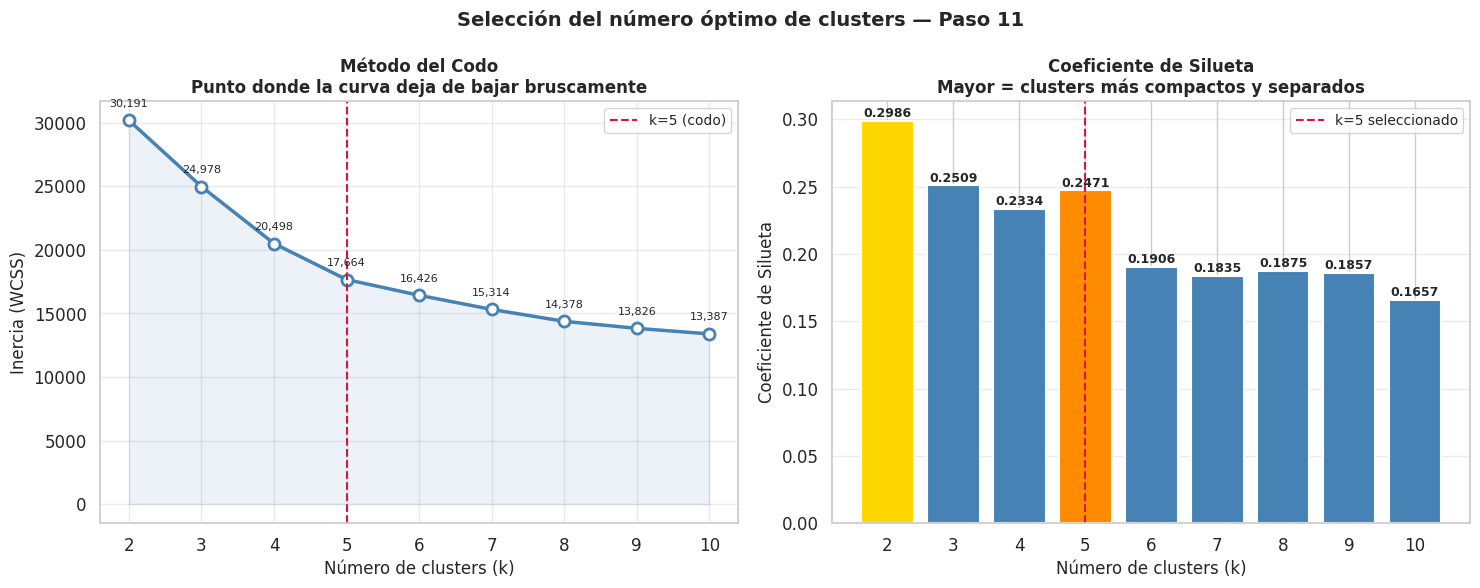

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Gráfico 1: Método del Codo ──
axes[0].plot(list(K_RANGE), inercias, 'o-', color='steelblue',
             lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(list(K_RANGE), inercias, alpha=0.1, color='steelblue')
for k, iner in zip(K_RANGE, inercias):
    axes[0].annotate(f'{iner:,.0f}', xy=(k, iner), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=8)
axes[0].axvline(x=5, color='crimson', ls='--', lw=1.5, label='k=5 (codo)')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Método del Codo\nPunto donde la curva deja de bajar bruscamente',
                  fontweight='bold', fontsize=12)
axes[0].set_xticks(list(K_RANGE))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# ── Gráfico 2: Silueta ──
colores = ['gold' if s == max(silhouettes) else
           'darkorange' if i == 3 else
           'steelblue' for i, s in enumerate(silhouettes)]
bars = axes[1].bar(list(K_RANGE), silhouettes, color=colores,
                   edgecolor='white', linewidth=1.5)
for bar, sil in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{sil:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axvline(x=5, color='crimson', ls='--', lw=1.5, label='k=5 seleccionado')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Coeficiente de Silueta', fontsize=12)
axes[1].set_title('Coeficiente de Silueta\nMayor = clusters más compactos y separados',
                  fontweight='bold', fontsize=12)
axes[1].set_xticks(list(K_RANGE))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4, axis='y')

plt.suptitle('Selección del número óptimo de clusters — Paso 11',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Interpretación y decisión del k óptimo**

**Decisión: k = 5.** Equilibra el punto de estabilización del codo, una silueta aceptable (0.2471) y cinco perfiles de cliente suficientes para diseñar estrategias diferenciadas de negocio.

---
## KMeans + Visualización PCA

Con k=5 definido, entrenamos el modelo definitivo. Usamos `init='k-means++'` para mejorar la inicialización de centroides y reducir el riesgo de convergencia a mínimos locales, y `n_init=20` para repetir el proceso con 20 semillas distintas conservando la mejor solución.

In [ ]:
k_final  = 5

km_final = KMeans(n_clusters=k_final, init='k-means++',
                  random_state=42, n_init=20, max_iter=500)

# Asignar clusters
df_modelo_copia = df_cluster_original_copia.copy()
df_modelo_copia['cluster'] = km_final.fit_predict(df_modelo)

sil_final = silhouette_score(df_modelo, df_modelo_copia['cluster'])

print(f"KMeans entrenado con k = {k_final}")
print(f"Inercia final        : {km_final.inertia_:,.2f}")
print(f"Iteraciones          : {km_final.n_iter_}")
print(f"Silhouette final     : {sil_final:.4f}")
print()
print("Distribución de clientes por cluster:")
dist = df_modelo_copia['cluster'].value_counts().sort_index()
for c, n in dist.items():
    pct = n / len(df_modelo_copia) * 100
    barra = '█' * int(pct / 2)
    print(f"  Cluster {c}: {barra} {n:,} clientes ({pct:.1f}%)")

KMeans entrenado con k = 5
Inercia final        : 17,664.14
Iteraciones          : 9
Silhouette final     : 0.2434

Distribución de clientes por cluster:
  Cluster 0: █████████████ 2,163 clientes (27.0%)
  Cluster 1: ███████████████████ 3,150 clientes (39.4%)
  Cluster 2: ██ 337 clientes (4.2%)
  Cluster 3: █████████ 1,537 clientes (19.2%)
  Cluster 4: █████ 813 clientes (10.2%)


Varianza explicada PC1: 44.2%
Varianza explicada PC2: 19.1%
Total capturada       : 63.3%


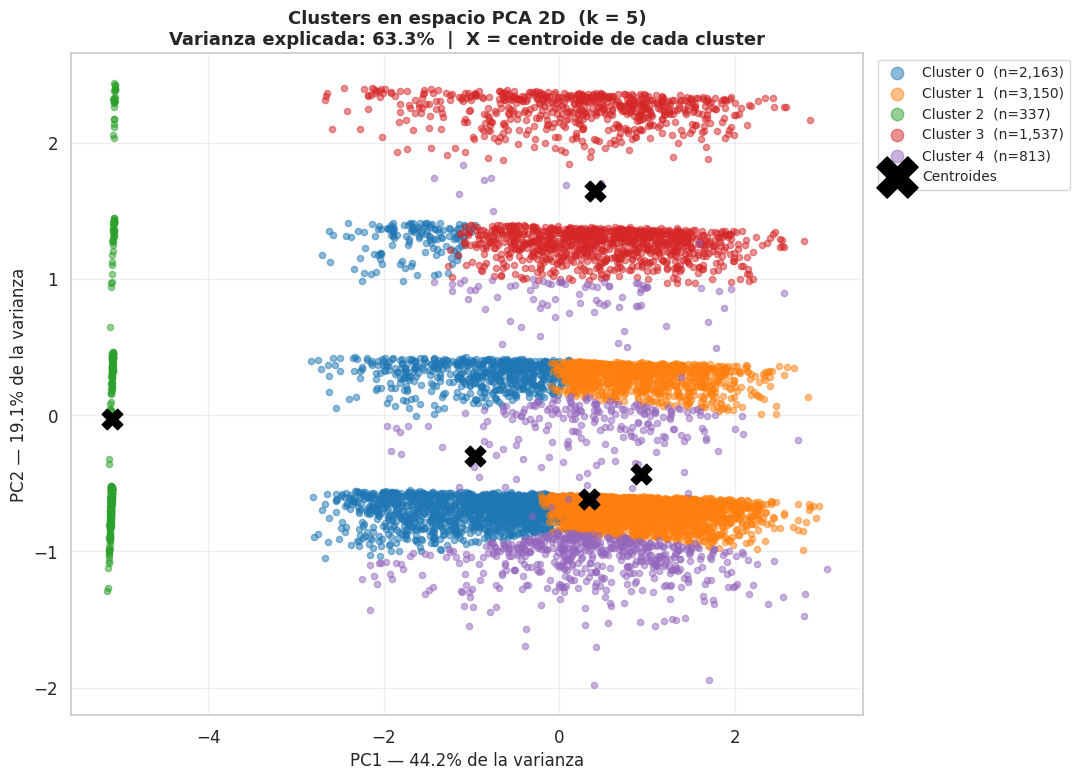

In [ ]:
# Visualización PCA 2D
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(df_modelo)
varianza = pca.explained_variance_ratio_

print(f"Varianza explicada PC1: {varianza[0]*100:.1f}%")
print(f"Varianza explicada PC2: {varianza[1]*100:.1f}%")
print(f"Total capturada       : {sum(varianza)*100:.1f}%")

palette_c = sns.color_palette('tab10', k_final)
fig, ax   = plt.subplots(figsize=(11, 8))

for cl in sorted(df_modelo_copia['cluster'].unique()):
    idx = df_modelo_copia['cluster'].values == cl
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=[palette_c[cl]], alpha=0.5, s=20,
               label=f'Cluster {cl}  (n={idx.sum():,})')

centroides_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=220, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 — {varianza[0]*100:.1f}% de la varianza', fontsize=12)
ax.set_ylabel(f'PC2 — {varianza[1]*100:.1f}% de la varianza', fontsize=12)
ax.set_title(
    f'Clusters en espacio PCA 2D  (k = {k_final})\n'
    f'Varianza explicada: {sum(varianza)*100:.1f}%  |  X = centroide de cada cluster',
    fontweight='bold', fontsize=13
)
ax.legend(markerscale=2, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretación KMeans + PCA**
Los dos componentes capturan el 63.3% de la varianza, suficiente para visualizar la segmentación. Se destacan dos hallazgos claros:

- **Cluster 2** (verde, n=337) queda completamente aislado a la izquierda, confirmando un perfil muy específico y diferenciado del resto.
- **Cluster 3** (rojo) se separa verticalmente de los demás, con un centroide bien distanciado.

El solapamiento entre Clusters 0, 1 y 4 es esperado en datos de comportamiento real donde los perfiles de cliente son graduales. La separación de los clusters extremos confirma que el modelo capturó estructura real en los datos.

---
## Perfilado e interpretación de clusters

Con los clusters asignados, analizamos el comportamiento real de cada segmento usando las medianas de las variables originales sin escalar. La mediana es más robusta que la media ante valores extremos y representa mejor al cliente típico de cada grupo.

In [ ]:
# Convertir membership_tier a número
mapeo_tier = {'Free': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
df_perfil_original['membership_tier'] = df_perfil_original['membership_tier'].map(mapeo_tier)

vars_perfil_orig = [
    'days_since_last_purchase',
    'total_ordenes_or',
    'total_comprado_usd_or',
    'total_descuento_usd_or',
    'cantidad_devoluciones_or',
    'cantidad_metodos_pago_or',
    'avg_session_min',
    'avg_delivery_days',
    'membership_tier',
    'age'
]

vars_perfil_orig = [v for v in vars_perfil_orig if v in df_perfil_original.columns]

perfil_med = df_perfil_original.groupby('cluster')[vars_perfil_orig].median().round(2)
perfil_med.loc['GLOBAL'] = df_perfil_original[vars_perfil_orig].median().round(2)

display(
    perfil_med.style
    .background_gradient(axis=0, cmap='RdYlGn_r',
                         subset=['days_since_last_purchase'])
    .background_gradient(axis=0, cmap='RdYlGn',
                         subset=['total_ordenes_or'])
    .background_gradient(axis=0, cmap='RdYlGn',
                         subset=['total_comprado_usd_or'])
    .background_gradient(axis=0, cmap='RdYlGn',
                         subset=['membership_tier'])
    .background_gradient(axis=0, cmap='RdYlGn_r',
                         subset=['cantidad_devoluciones_or'])
    .format(precision=2)
)
print('Verde = mejor valor | Rojo = peor valor | GLOBAL = referencia')
print('membership_tier: 0=Free, 1=Silver, 2=Gold, 3=Platinum')

NameError: name 'df_perfil_original' is not defined

In [ ]:
etiquetas_cluster = {
    0: 'Comprador Ocasional',
    1: 'Comprador Frecuente',
    2: 'Cliente Inactivo',
    3: 'Cliente Leal Premium',
    4: 'Cliente en Riesgo'
}

df_perfil_original['cluster_label'] = df_perfil_original['cluster'].map(etiquetas_cluster)
df_modelo_copia['cluster_label']    = df_modelo_copia['cluster'].map(etiquetas_cluster)

print("Etiquetas asignadas:")
for k, v in etiquetas_cluster.items():
    n = (df_perfil_original['cluster'] == k).sum()
    pct = n / len(df_perfil_original) * 100
    print(f"  Cluster {k} — {v}: {n:,} clientes ({pct:.1f}%)")

### **Perfiles identificados**

| Cluster | Nombre | Clientes | Característica principal |
|---|---|---|---|
| 0 | Comprador Ocasional | 2.163 (27.0%) | Pocas órdenes, gasto bajo, sin membresía |
| 1 | Comprador Frecuente | 3.150 (39.4%) | Mayor frecuencia y gasto, aprovecha descuentos |
| 2 | Cliente Inactivo | 337 (4.2%) | Registrados sin ninguna orden completada |
| 3 | Cliente Leal Premium | 1.537 (19.2%) | Membresía Gold, gasto medio-alto, fidelizados |
| 4 | Cliente en Riesgo | 813 (10.2%) | Mayor recencia, lleva más días sin comprar |

El Cluster 1 concentra el mayor volumen de clientes y el mayor gasto promedio, siendo el segmento más valioso en términos de ingreso. El Cluster 2 representa una oportunidad de activación — clientes que se registraron pero nunca concretaron una compra. El Cluster 4 requiere atención inmediata de retención dado su alto indicador de recencia.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

vars_radar = [
    'days_since_last_purchase',
    'total_ordenes_or',
    'total_comprado_usd_or',
    'total_descuento_usd_or',
    'cantidad_metodos_pago_or',
    'avg_session_min',
    'avg_delivery_days',
    'membership_tier',
    'age'
]

vars_radar = [v for v in vars_radar if v in df_perfil_original.columns]

# Calcular medias por cluster (excluir Cluster 2 — sin órdenes)
df_radar = df_perfil_original[df_perfil_original['cluster'] != 2].copy()
medias   = df_radar.groupby('cluster')[vars_radar].mean()

# Normalizar 0-1
mms  = MinMaxScaler()
norm = pd.DataFrame(mms.fit_transform(medias),
                    columns=vars_radar, index=medias.index)

# Invertir variables donde MENOS = MEJOR
for col_inv in ['days_since_last_purchase', 'avg_delivery_days']:
    if col_inv in norm.columns:
        norm[col_inv] = 1 - norm[col_inv]

labels_radar = [
    'Recencia\n(inv)', 'Frecuencia', 'Monetario',
    'Descuentos', 'Métodos pago', 'Sesión',
    'Entrega\n(inv)', 'Membresía', 'Edad'
][:len(vars_radar)]

N       = len(vars_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos_c = angulos + angulos[:1]

palette_c = sns.color_palette('tab10', 5)
colores_radar = {0: palette_c[0], 1: palette_c[1],
                 3: palette_c[3], 4: palette_c[4]}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cl in norm.index:
    vals  = norm.loc[cl].tolist() + norm.loc[cl].tolist()[:1]
    label = etiquetas_cluster[cl]
    ax.plot(angulos_c, vals, lw=2.5, color=colores_radar[cl],
            label=f'Cluster {cl} — {label}')
    ax.fill(angulos_c, vals, alpha=0.1, color=colores_radar[cl])

ax.set_thetagrids(np.degrees(angulos), labels_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=8)
ax.set_title(
    'Perfil de comportamiento por cluster\n'
    '(normalizado 0-1 | variables (inv) = invertidas, mayor es mejor)\n'
    'Cluster 2 excluido — clientes sin órdenes',
    fontweight='bold', fontsize=12, pad=25
)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

### **Interpretación del Radar Chart**

El gráfico confirma los perfiles asignados. El **Cluster 1** domina en Monetario, Frecuencia y Descuentos, siendo el segmento más valioso. El **Cluster 3** se diferencia claramente por su nivel de Membresía, confirmando su fidelización. El **Cluster 4** muestra un perfil similar al 3 pero con menor recencia, señal de alejamiento de la plataforma. El **Cluster 0** presenta la superficie más pequeña, coherente con su bajo nivel de actividad.

Las variables **Membresía** y **Entrega** son las que más diferencian los segmentos, mientras que **Edad** y **Sesión** aportan poca discriminación entre grupos.

---
### **Interpretación del Análisis RFM****

Calculamos scores R, F, M por quintiles (1 = peor, 5 = mejor) para cada cliente y los promediamos por cluster. El RFM_score total (rango 3-15) resume el valor de cada segmento y permite priorizarlos para acciones comerciales.

In [ ]:
df_rfm = df_perfil_original[['customer_id', 'cluster', 'cluster_label',
                              'days_since_last_purchase',
                              'total_ordenes_or',
                              'total_comprado_usd_or']].dropna().copy()

# Recencia: menos días = más reciente = score 5
df_rfm['R_score'] = pd.qcut(
    df_rfm['days_since_last_purchase'],
    q=5, labels=[5, 4, 3, 2, 1], duplicates='drop'
).astype(int)

# Frecuencia: más órdenes = score 5
df_rfm['F_score'] = pd.qcut(
    df_rfm['total_ordenes_or'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetario: mayor gasto = score 5
df_rfm['M_score'] = pd.qcut(
    df_rfm['total_comprado_usd_or'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']

print("Distribución de RFM_score total (3-15):")
display(df_rfm['RFM_score'].describe().to_frame().T.style.format(precision=1))

In [ ]:
# Perfil RFM por cluster
rfm_cluster = df_rfm.groupby(['cluster', 'cluster_label']).agg(
    n_clientes    = ('customer_id',             'count'),
    R_score       = ('R_score',                 'mean'),
    F_score       = ('F_score',                 'mean'),
    M_score       = ('M_score',                 'mean'),
    RFM_total     = ('RFM_score',               'mean'),
    R_dias_med    = ('days_since_last_purchase', 'median'),
    F_ordenes_med = ('total_ordenes_or',         'median'),
    M_gasto_med   = ('total_comprado_usd_or',    'median'),
).round(2)

rfm_cluster.index = [f'Cluster {cl} — {lbl}'
                     for cl, lbl in rfm_cluster.index]

display(
    rfm_cluster.style
    .background_gradient(subset=['R_score'],   cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['F_score'],   cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['M_score'],   cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['RFM_total'], cmap='RdYlGn', vmin=3, vmax=15)
    .format(precision=2)
)
print('RFM_total: 3 = peor, 15 = mejor | Verde = mayor valor')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap scores RFM
pivot_rfm = df_rfm.groupby('cluster')[['R_score','F_score','M_score']].mean().round(2)
pivot_rfm.index = [etiquetas_cluster[i] for i in pivot_rfm.index]
pivot_rfm.columns = ['Recencia (R)', 'Frecuencia (F)', 'Monetario (M)']

sns.heatmap(pivot_rfm, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], vmin=1, vmax=5,
            cbar_kws={'label': 'Score (1=peor, 5=mejor)'})
axes[0].set_title('Scores RFM por cluster\n(mayor = mejor comportamiento de compra)',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('')

# Barras RFM total
rfm_tot = df_rfm.groupby('cluster')['RFM_score'].mean().sort_values(ascending=True)
palette_c = sns.color_palette('tab10', 5)
bars = axes[1].barh(
    [etiquetas_cluster[i] for i in rfm_tot.index],
    rfm_tot.values,
    color=[palette_c[i] for i in rfm_tot.index],
    edgecolor='white', alpha=0.85
)
for bar, val in zip(bars, rfm_tot.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontweight='bold', fontsize=11)
axes[1].set_xlabel('RFM Score promedio (3-15)', fontsize=11)
axes[1].set_title('RFM total por cluster\n(15 = comprador ideal)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlim(0, 16)
axes[1].axvline(9, color='gray', ls='--', lw=1.2, alpha=0.6,
                label='Punto medio (9)')
axes[1].legend(fontsize=10)

plt.suptitle('Análisis RFM por cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Análisis RFM por Cluster**

El heatmap y el ranking RFM confirman y cuantifican los perfiles identificados:

- **Comprador Frecuente (10.74):** lidera el ranking con los scores más altos en Frecuencia (3.90) y Monetario (3.81). Es el segmento más valioso del negocio y el prioritario para estrategias de fidelización.
- **Cliente Leal Premium (9.36)** y **Cliente en Riesgo (9.17):** ambos superan el punto medio (9) con perfiles RFM similares. La diferencia clave está en la recencia — el Cliente en Riesgo lleva más días sin comprar (46 vs 40), señal de alejamiento que requiere intervención.
- **Comprador Ocasional (6.19):** único segmento por debajo del punto medio. Sus scores bajos en Frecuencia (1.53) y Monetario (1.65) lo identifican como el segmento de menor valor actual pero con mayor potencial de desarrollo.

La Recencia es similar en todos los clusters activos (~3.0), lo que indica que la principal diferencia entre segmentos está en **cuánto y con qué frecuencia compran**, no en cuándo fue su última compra.

---
## **Evaluación del Modelo**

La evaluación de modelos de clustering se realiza con métricas internas dado que no existe una etiqueta real contra la cual comparar. Usamos tres métricas complementarias:

- **Silhouette Score:** mide qué tan similar es cada cliente a su propio cluster vs los demás. Rango [-1,1], mayor es mejor.
- **Davies-Bouldin:** mide la similitud promedio entre clusters. Menor es mejor.
- **Calinski-Harabasz:** mide la relación entre varianza entre clusters y varianza interna. Mayor es mejor.

Adicionalmente validamos externamente con la variable `churned`, que fue excluida del entrenamiento, para verificar si los clusters capturaron diferencias reales en el comportamiento de abandono.

In [ ]:
from sklearn.metrics import (silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)

print("=" * 55)
print("  EVALUACIÓN DEL MODELO K-MEANS")
print("=" * 55)

sil = silhouette_score(df_modelo, df_modelo_copia['cluster'])
db  = davies_bouldin_score(df_modelo, df_modelo_copia['cluster'])
ch  = calinski_harabasz_score(df_modelo, df_modelo_copia['cluster'])

print(f"\n  Silhouette Score     : {sil:.4f}  (mayor = mejor)")
print(f"  Davies-Bouldin       : {db:.4f}  (menor = mejor)")
print(f"  Calinski-Harabasz    : {ch:.2f}  (mayor = mejor)")
print()
print("-" * 55)
print("  DIAGNÓSTICO")
print("-" * 55)

if sil >= 0.5:
    print(f"  Silhouette EXCELENTE : clusters bien definidos")
elif sil >= 0.20:
    print(f"  Silhouette ACEPTABLE : estructura razonable,")
    print(f"  típica en datos de comportamiento real")
else:
    print(f"  Silhouette BAJO      : revisar k")

if db <= 1.0:
    print(f"  Davies-Bouldin BUENO : clusters bien separados")
elif db <= 2.0:
    print(f"  Davies-Bouldin ACEPTABLE : separación moderada")

print(f"  Calinski-Harabasz    : {ch:.2f} (mayor = mejor)")
print("=" * 55)

### **Interpretación de métricas**

Las tres métricas en conjunto validan el modelo. El Silhouette de 0.2434 es aceptable para datos de comportamiento de compra donde los perfiles de cliente son graduales. El Calinski-Harabasz de 2591.02 confirma que los clusters son internamente compactos. El Davies-Bouldin de 1.2083 indica separación moderada entre grupos, esperada cuando se trabaja con perfiles de e-commerce reales.

In [ ]:
# Recuperar churned desde df_cust
y_validacion = df_cust.set_index('customer_id')['churned']
y_validacion = y_validacion.reindex(
    df_perfil_original['customer_id']
).values

print(f"Churned recuperado: {len(y_validacion)} registros")
print(f"Tasa global de churn: {y_validacion.mean()*100:.1f}%")
print(f"Nulos: {pd.isnull(y_validacion).sum()}")

In [ ]:
print("=" * 55)
print("  VALIDACIÓN EXTERNA CON VARIABLE CHURNED")
print("=" * 55)
print("Variable excluida del entrenamiento — usada solo para validar")
print()

df_val = df_modelo_copia[['cluster', 'cluster_label']].copy()
df_val['churned'] = y_validacion

churn_cluster = df_val.groupby(['cluster','cluster_label'])['churned'].agg(
    n_total  = 'count',
    n_churn  = 'sum',
    tasa_pct = 'mean'
).round(4)
churn_cluster['tasa_pct'] = (churn_cluster['tasa_pct'] * 100).round(2)

display(
    churn_cluster.style
    .background_gradient(subset=['tasa_pct'], cmap='RdYlGn_r')
    .format({'tasa_pct': '{:.2f}%', 'n_total': '{:,}', 'n_churn': '{:,}'})
)

tasa_global = df_val['churned'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
palette_c = sns.color_palette('tab10', 5)
clusters_plot = churn_cluster.reset_index()
bars = ax.bar(
    clusters_plot['cluster_label'],
    clusters_plot['tasa_pct'],
    color=[palette_c[i] for i in clusters_plot['cluster']],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, clusters_plot['tasa_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center',
            fontsize=11, fontweight='bold')
ax.axhline(tasa_global, color='red', ls='--', lw=2,
           label=f'Tasa global: {tasa_global:.1f}%')
ax.set_ylabel('Tasa de Churn (%)', fontsize=12)
ax.set_title('Tasa de abandono (churn) por cluster\n'
             'Variable no usada en el entrenamiento — validación externa',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### **Interpretación — Validación externa con Churn**

La variable `churned` no participó en el entrenamiento del modelo, por lo que su comportamiento diferenciado entre clusters confirma que K-Means capturó estructura real en los datos.

El **Cliente en Riesgo** presenta la tasa más alta (10.3%), superando la media global (8.9%), lo que valida su nombre — son clientes que efectivamente abandonan más. El **Cliente Inactivo** tiene la tasa más baja (7.4%), coherente con que son clientes registrados que nunca compraron y por tanto no generan churn transaccional. Los demás clusters se mantienen cerca de la media global, con el **Comprador Frecuente** ligeramente por encima (9.0%) a pesar de ser el segmento más valioso, lo que sugiere una oportunidad de fidelización activa.

La diferenciación en tasas de churn entre segmentos, aunque moderada, confirma que el modelo tiene **valor predictivo implícito** y que los perfiles identificados son estadística y comercialmente válidos.

In [ ]:
print("=" * 60)
print("  RESUMEN DE EVALUACIÓN DEL MODELO")
print("=" * 60)

resumen_eval = pd.DataFrame({
    'Métrica'        : ['Silhouette Score', 'Davies-Bouldin',
                        'Calinski-Harabasz', 'Tasa Churn diferenciada'],
    'Valor'          : [f'{sil:.4f}', f'{db:.4f}',
                        f'{ch:.2f}', 'Sí (7.4% — 10.3%)'],
    'Referencia'     : ['Mayor es mejor', 'Menor es mejor',
                        'Mayor es mejor', 'Confirma validez externa'],
    'Calificación'   : ['Aceptable ✓', 'Aceptable ✓',
                        'Bueno ✓', 'Válido ✓']
})

display(resumen_eval.style
    .applymap(lambda v: 'color: green; font-weight: bold'
              if '✓' in str(v) else '', subset=['Calificación'])
    .hide(axis='index')
)

print()
print("Conclusión: modelo estadísticamente aceptable y")
print("comercialmente válido para segmentación de clientes.")

---
## **Calificación general del modelo**

El modelo obtiene calificación **Aceptable-Bueno** en el conjunto de métricas evaluadas. El Calinski-Harabasz destaca como el indicador más favorable, confirmando que los clusters son internamente compactos. La validación externa con `churned` cierra la evaluación demostrando que los segmentos tienen valor predictivo real más allá de las métricas geométricas.\

---
## **Conclusiones y Recomendaciones Estratégicas**

El modelo de segmentación identificó cinco perfiles de cliente con comportamientos de compra diferenciados. A continuación se presentan las conclusiones del análisis y las acciones recomendadas para cada segmento.

In [ ]:
print("=" * 60)
print("  RESUMEN EJECUTIVO — SEGMENTACIÓN DE CLIENTES")
print("=" * 60)

resumen_final = df_perfil_original.groupby(
    ['cluster', 'cluster_label']).agg(
    n_clientes          = ('customer_id',             'count'),
    recencia_media      = ('days_since_last_purchase', 'median'),
    frecuencia_media    = ('total_ordenes_or',         'median'),
    gasto_mediano_usd   = ('total_comprado_usd_or',    'median'),
).round(2)

resumen_final['pct_clientes'] = (
    resumen_final['n_clientes'] /
    resumen_final['n_clientes'].sum() * 100
).round(1)

resumen_final.index = [f'Cluster {cl} — {lbl}'
                       for cl, lbl in resumen_final.index]

display(
    resumen_final.style
    .background_gradient(subset=['gasto_mediano_usd'], cmap='Greens')
    .background_gradient(subset=['recencia_media'],    cmap='RdYlGn_r')
    .background_gradient(subset=['frecuencia_media'],  cmap='Blues')
    .format({
        'gasto_mediano_usd' : '${:,.2f}',
        'pct_clientes'      : '{:.1f}%',
        'recencia_media'    : '{:.0f} días',
        'frecuencia_media'  : '{:.0f} órdenes'
    })
)

### **Recomendaciones estratégicas por segmento**

| Segmento | Clientes | Acción recomendada |
|---|---|---|
| **Comprador Frecuente** | 3.150 (39.4%) | Programa de fidelización premium. Son el motor de ingresos — protegerlos con beneficios exclusivos y acceso anticipado a productos |
| **Comprador Ocasional** | 2.163 (27.0%) | Estrategia de activación. Incentivar la segunda y tercera compra con descuentos progresivos y recomendaciones personalizadas |
| **Cliente Leal Premium** | 1.537 (19.2%) | Upselling y cross-selling. Ya tienen membresía Gold — ofrecerles categorías complementarias y beneficios de nivel Platinum |
| **Cliente en Riesgo** | 813 (10.2%) | Reactivación urgente. Mayor recencia y mayor churn (10.3%) — campaña personalizada con oferta de alto impacto en los próximos 30 días |
| **Cliente Inactivo** | 337 (4.2%) | Campaña de primera compra. Se registraron pero nunca compraron — email de bienvenida con descuento de activación o dar de baja la comunicación |

### **Conclusión general**

El modelo de clustering con K-Means y análisis RFM permitió segmentar 8.000 clientes en cinco perfiles diferenciados y accionables. El Comprador Frecuente concentra el mayor volumen e ingresos y debe ser la prioridad de retención. El Cliente en Riesgo requiere intervención inmediata dado su mayor propensión al abandono. Los Clientes Inactivos, aunque minoritarios, representan una oportunidad de conversión con bajo costo de adquisición.
Las métricas de evaluación confirman que el modelo capturó estructura real en los datos, siendo estadísticamente aceptable y comercialmente válido para la toma de decisiones de marketing
